# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFECV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras import regularizers 
import keras_tuner as kt 
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from imblearn.over_sampling import SMOTENC, ADASYN, RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
# CELL 1
import os

# This line MUST be executed before TensorFlow is imported for the first time.
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Now, this check will correctly show that no GPUs are visible.
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Import Data

In [3]:
Column_Names = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race',
                'sex','capital_gain','capital_loss','hours_per_week','native_country','Income']

Adult_Data = pd.read_csv('adult.data', sep=',', header=None, names=Column_Names, skipinitialspace=True)
Adult_Test = pd.read_csv('adult.test', sep=',', header=None, names=Column_Names, skiprows=[0], skipinitialspace=True)

In [4]:
Adult_Data.head(6)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [5]:
Adult_Test.head(6)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,Income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K.


In [6]:
Adult_Test['Income'] = Adult_Test['Income'].str.strip().str.replace('.', '', regex=False)

In [7]:
print(f'Number of Samples: {Adult_Data.shape[0]}')
print(f'Number of Columns: {Adult_Data.shape[1]}\n')
print('******************************')
print('******************************\n')
print(f'Number of Test Samples: {Adult_Test.shape[0]}')
print(f'Number of Test Columns: {Adult_Test.shape[1]}')

Number of Samples: 32561
Number of Columns: 15

******************************
******************************

Number of Test Samples: 16281
Number of Test Columns: 15


In [8]:
Adult_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
print('Numerical Features:\n{}\n'.format(Adult_Data.select_dtypes('int64').columns.to_list()))
print('Categorical Features:\n{}'.format(Adult_Data.select_dtypes('object').columns.to_list()))

Numerical Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'Income']


In [10]:
for name in Column_Names:
    print(f'Column {name}:\n {Adult_Data[name].unique()}\n')

Column age:
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Column workclass:
 ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Column fnlwgt:
 [ 77516  83311 215646 ...  34066  84661 257302]

Column education:
 ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Column education_num:
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Column marital_status:
 ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Column occupation:
 ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 '

# Missing Values

In [11]:
Adult_Data = Adult_Data.replace('?', np.nan)
Adult_Test = Adult_Test.replace('?', np.nan)

In [12]:
null_counts = pd.DataFrame({
    '# Train Missing Values': Adult_Data.isnull().sum(),
    '# Test Missing Values': Adult_Test.isnull().sum()
})

print(null_counts)

                # Train Missing Values  # Test Missing Values
age                                  0                      0
workclass                         1836                    963
fnlwgt                               0                      0
education                            0                      0
education_num                        0                      0
marital_status                       0                      0
occupation                        1843                    966
relationship                         0                      0
race                                 0                      0
sex                                  0                      0
capital_gain                         0                      0
capital_loss                         0                      0
hours_per_week                       0                      0
native_country                     583                    274
Income                               0                      0


In [13]:
null_counts_pct = pd.DataFrame({
    'Train Missing Values percentage (%)': np.round((Adult_Data.isnull().sum() *100) / Adult_Data.shape[0], decimals=1),
    'Test Missing Values percentage (%)': np.round((Adult_Test.isnull().sum() *100) / Adult_Test.shape[0], decimals=1)
})

null_counts_pct

,Train Missing Values percentage (%),Test Missing Values percentage (%)
age,0.0,0.0
workclass,5.6,5.9
fnlwgt,0.0,0.0
education,0.0,0.0
education_num,0.0,0.0
marital_status,0.0,0.0
occupation,5.7,5.9
relationship,0.0,0.0
race,0.0,0.0
sex,0.0,0.0


In [14]:
# # % The first option is choosing a specific value for Nan based on other similar data %

# for i in range(3):

#     if i == 0:

#         # Train & Validation Part
#         Adult_Data['workclass'] = Adult_Data['workclass'].fillna(Adult_Data.groupby(['age','education','sex'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['occupation'] = Adult_Data['occupation'].fillna(Adult_Data.groupby(['age','education','sex'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['native_country'] = Adult_Data['native_country'].fillna(Adult_Data.groupby(['age','education','sex'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         # Test Part
#         Adult_Test['workclass'] = Adult_Test['workclass'].fillna(Adult_Test.groupby(['age','education','sex'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['occupation'] = Adult_Test['occupation'].fillna(Adult_Test.groupby(['age','education','sex'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['native_country'] = Adult_Test['native_country'].fillna(Adult_Test.groupby(['age','education','sex'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
       
#     elif i == 1:

#         # Train & Validation Part
#         Adult_Data['workclass'] = Adult_Data['workclass'].fillna(Adult_Data.groupby(['age','education'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['occupation'] = Adult_Data['occupation'].fillna(Adult_Data.groupby(['age','education'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['native_country'] = Adult_Data['native_country'].fillna(Adult_Data.groupby(['age','education'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         # Test Part
#         Adult_Test['workclass'] = Adult_Test['workclass'].fillna(Adult_Test.groupby(['age','education'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['occupation'] = Adult_Test['occupation'].fillna(Adult_Test.groupby(['age','education'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['native_country'] = Adult_Test['native_country'].fillna(Adult_Test.groupby(['age','education'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#     else:
        
#         # Train & Validation Part
#         Adult_Data['workclass'] = Adult_Data['workclass'].fillna(Adult_Data.groupby(['sex'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['occupation'] = Adult_Data['occupation'].fillna(Adult_Data.groupby(['sex'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Data['native_country'] = Adult_Data['native_country'].fillna(Adult_Data.groupby(['sex'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         # Test Part
#         Adult_Test['workclass'] = Adult_Test['workclass'].fillna(Adult_Test.groupby(['sex'])['workclass']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['occupation'] = Adult_Test['occupation'].fillna(Adult_Test.groupby(['sex'])['occupation']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode()))
        
#         Adult_Test['native_country'] = Adult_Test['native_country'].fillna(Adult_Test.groupby(['sex'])['native_country']
#                                                          .transform(lambda y: y.mode()[0] if not y.mode().empty else y.mode())) 

In [15]:
## % The second option is choosing "Unknown" for the Nan value %

Adult_Data.fillna('Unknown', axis=0, inplace=True)
Adult_Test.fillna('Unknown', axis=0, inplace=True)

In [16]:
null_counts = pd.DataFrame({
    'Train Nulls': Adult_Data.isnull().sum(),
    'Test Nulls': Adult_Test.isnull().sum()
})

print("Missing Values (After assigning an unknown label to Nan Values) :\n")
print(null_counts)

Missing Values (After assigning an unknown label to Nan Values) :

                Train Nulls  Test Nulls
age                       0           0
workclass                 0           0
fnlwgt                    0           0
education                 0           0
education_num             0           0
marital_status            0           0
occupation                0           0
relationship              0           0
race                      0           0
sex                       0           0
capital_gain              0           0
capital_loss              0           0
hours_per_week            0           0
native_country            0           0
Income                    0           0


# Duplicated Data

In [17]:
print('Number of duplicated data in Train dataset: {}\n'.format(Adult_Data.duplicated(keep='first').sum()))
print('Number of duplicated data in Test dataset: {}\n'.format(Adult_Test.duplicated(keep='first').sum()))

Adult_Data.drop_duplicates(inplace=True)
Adult_Data.reset_index(inplace=True)
Adult_Data.drop(columns='index',axis=1, inplace=True)


Adult_Test.drop_duplicates(inplace=True)
Adult_Test.reset_index(inplace=True)
Adult_Test.drop(columns='index',axis=1, inplace=True)

Number of duplicated data in Train dataset: 24

Number of duplicated data in Test dataset: 5



In [18]:
print(f'Number of Samples: {Adult_Data.shape[0]}')
print(f'Number of Columns: {Adult_Data.shape[1]}')
print(f'Number of Test Samples: {Adult_Test.shape[0]}')
print(f'Number of Test Columns: {Adult_Test.shape[1]}')

Number of Samples: 32537
Number of Columns: 15
Number of Test Samples: 16276
Number of Test Columns: 15


# Visualize Data

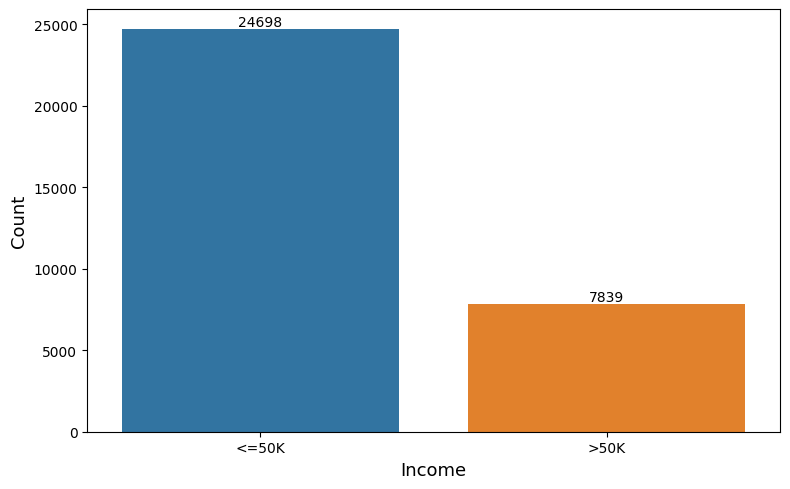

In [19]:
plt.figure(figsize=(8,5))
ordered = Adult_Data['Income'].value_counts().index
P = sns.countplot(x='Income', data=Adult_Data, hue='Income', legend=False, order=ordered)
plt.xlabel('Income', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

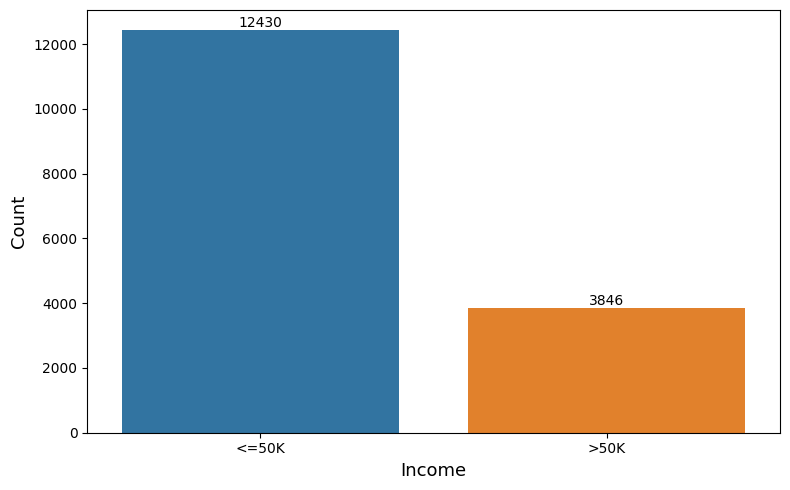

In [20]:
plt.figure(figsize=(8,5))
ordered = Adult_Test['Income'].value_counts().index
P = sns.countplot(x='Income', data=Adult_Test, hue='Income', legend=False, order=ordered)
plt.xlabel('Income', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## work class Exploration 

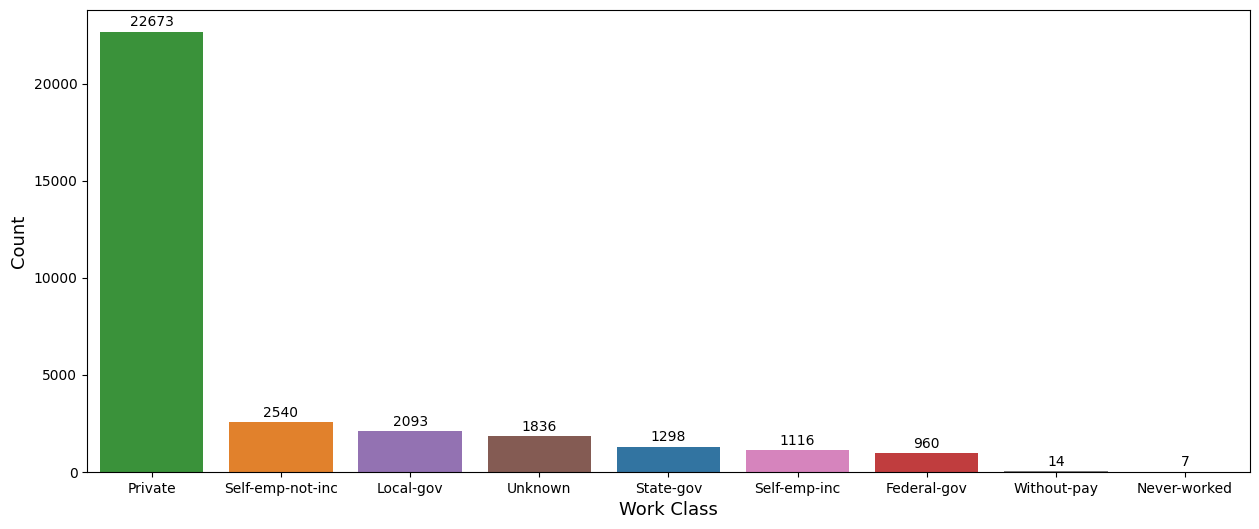

In [21]:
plt.figure(figsize=(15,6))
ordered = Adult_Data['workclass'].value_counts().index
P = sns.countplot(x='workclass', data=Adult_Data, hue='workclass', legend=False, order=ordered)
plt.xlabel('Work Class', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points')
plt.xticks(fontsize=10)
plt.show()

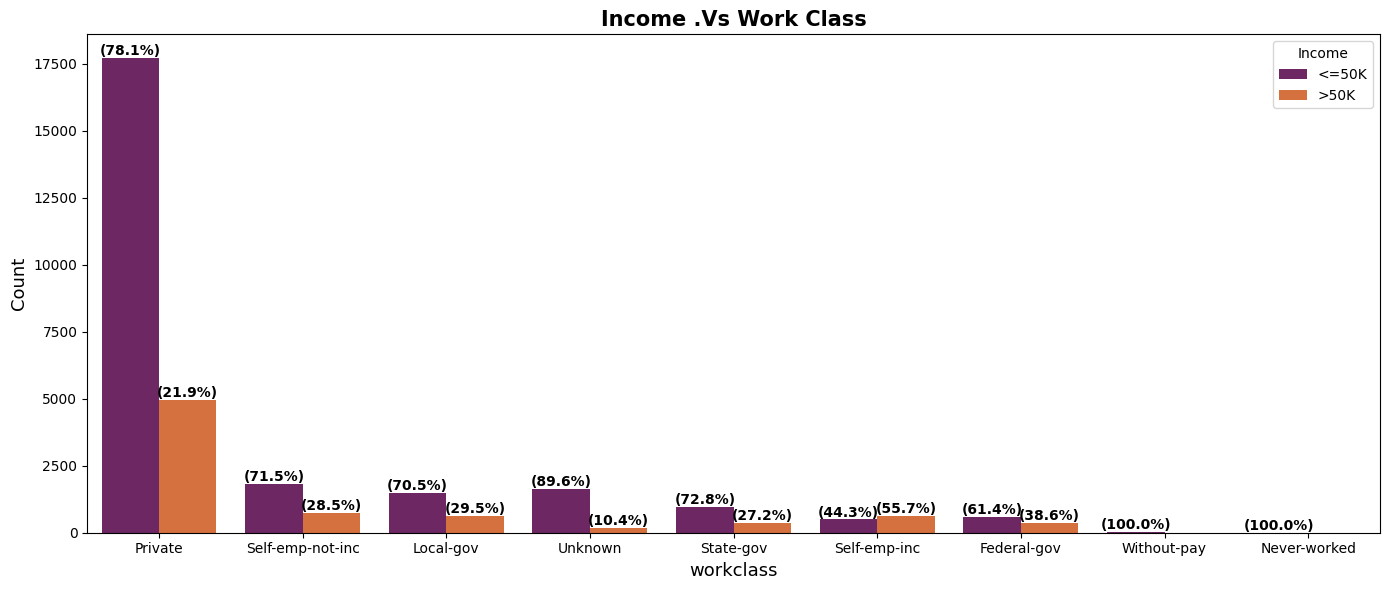

In [22]:
plt.figure(figsize=(14,6))
ordered = Adult_Data['workclass'].value_counts().index
P = sns.countplot(x='workclass', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='inferno')

max_len = max(len(c.datavalues) for c in P.containers)
totals = np.zeros(max_len)

for container in P.containers:
    vals = np.zeros(max_len)
    vals[:len(container.datavalues)] = container.datavalues
    totals += vals

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')
        

plt.xlabel('workclass', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.title('Income .Vs Work Class', weight='bold', fontsize=15)
plt.tight_layout()
plt.xticks(fontsize=10)
plt.show()

##### As shown in the figure, self-emp-inc and federal-gov in the Workclass category have a higher chance of earning more than 50K

## Occupation Exploration

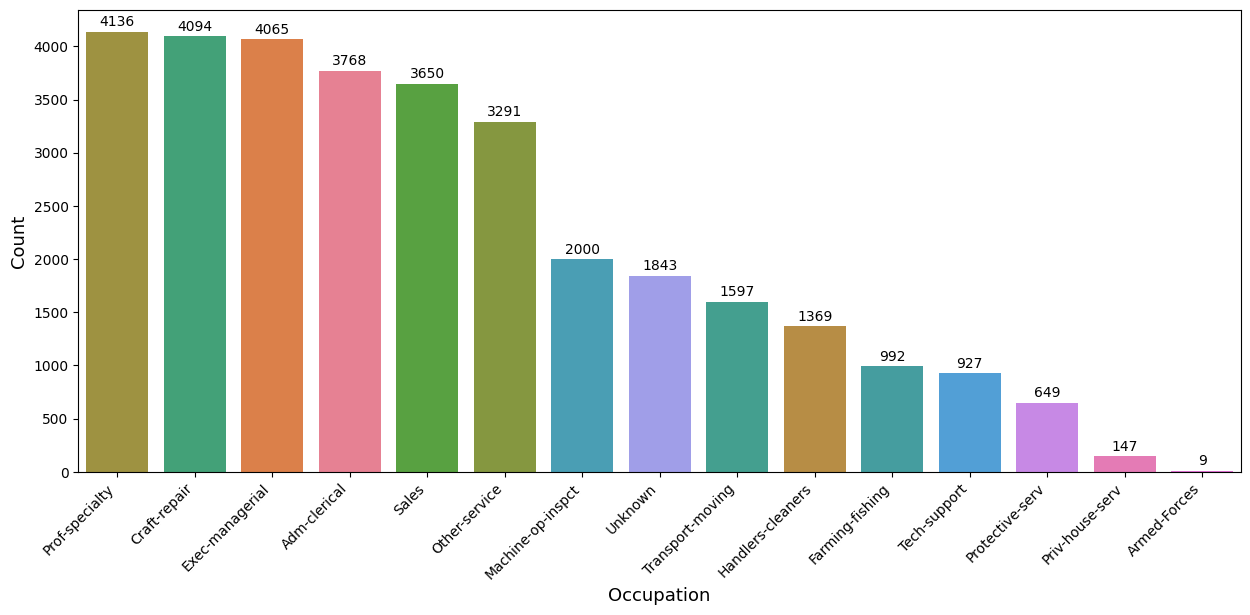

In [23]:
plt.figure(figsize=(15,6))
ordered = Adult_Data['occupation'].value_counts().index
P = sns.countplot(x='occupation', data=Adult_Data, hue='occupation', legend=False, order=ordered)
plt.xlabel('Occupation', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

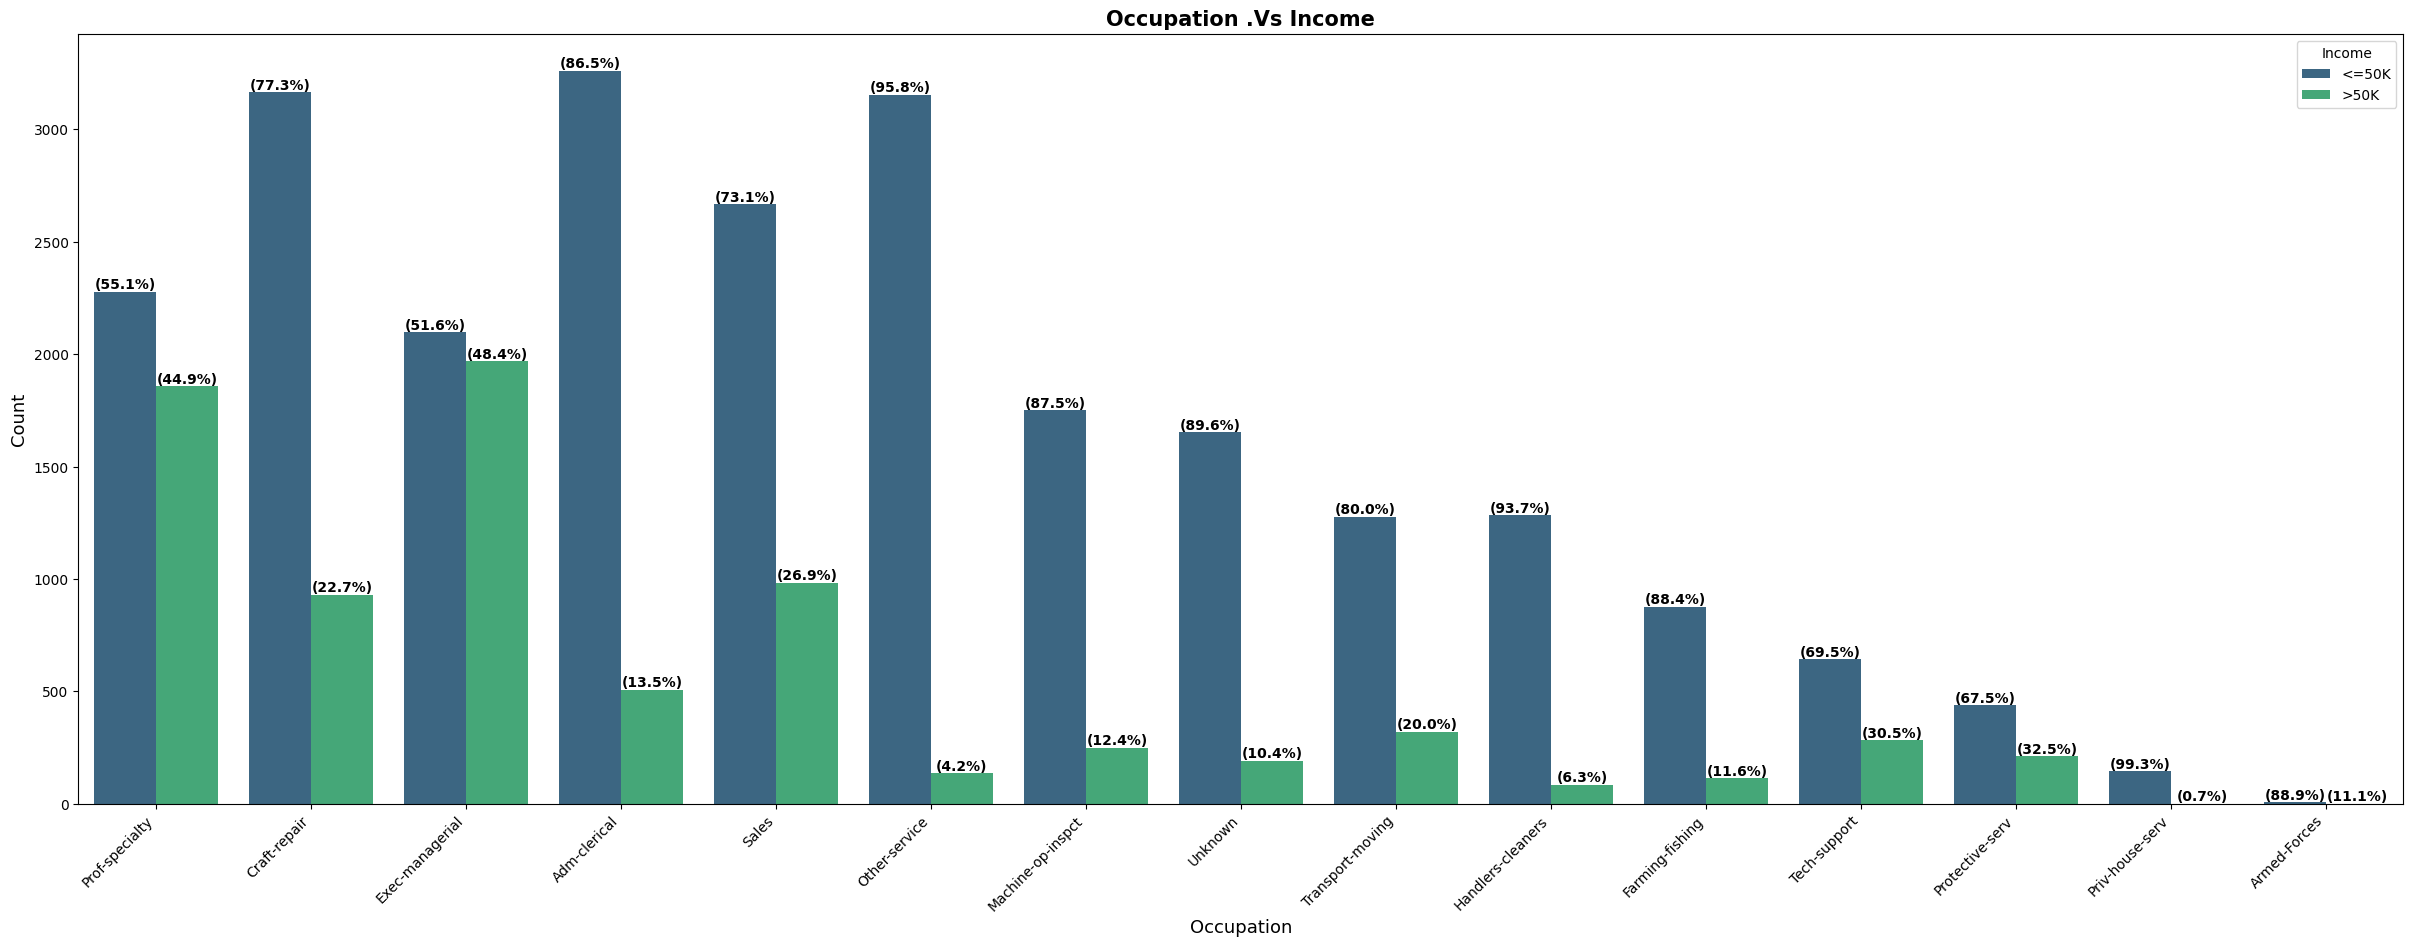

In [24]:
plt.figure(figsize=(30,10))
ordered = Adult_Data['occupation'].value_counts().index
P = sns.countplot(x='occupation', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='viridis')

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')
    
plt.xlabel('Occupation', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.title('Occupation .Vs Income', weight='bold', fontsize=15)
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

##### It can be seen in Occupation Bar Chart that Prof-specialty and Exec-managerial have a higher chance of earning more than 50K

## Nationality Exploration

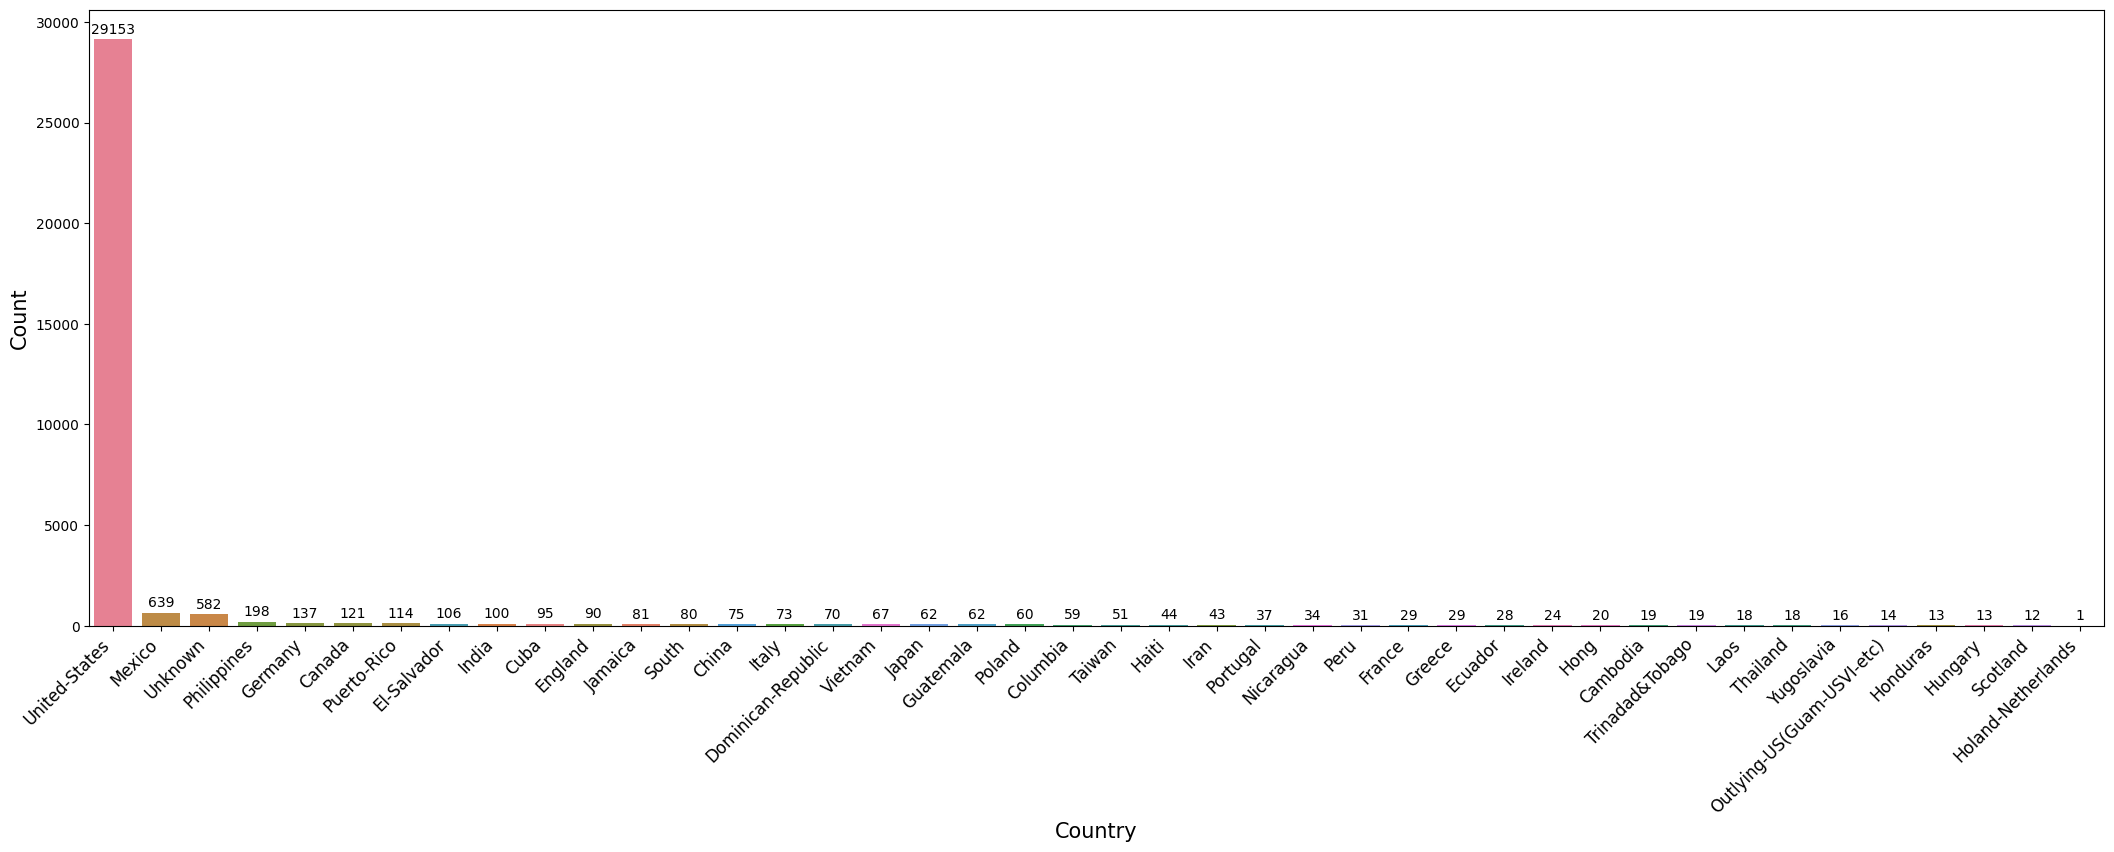

In [25]:
plt.figure(figsize=(26,8))
ordered = Adult_Data['native_country'].value_counts().index
P = sns.countplot(x='native_country', data=Adult_Data, hue='native_country', legend=False, order=ordered)
plt.xlabel('Country', fontsize=15)
plt.ylabel('Count',fontsize=15)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()

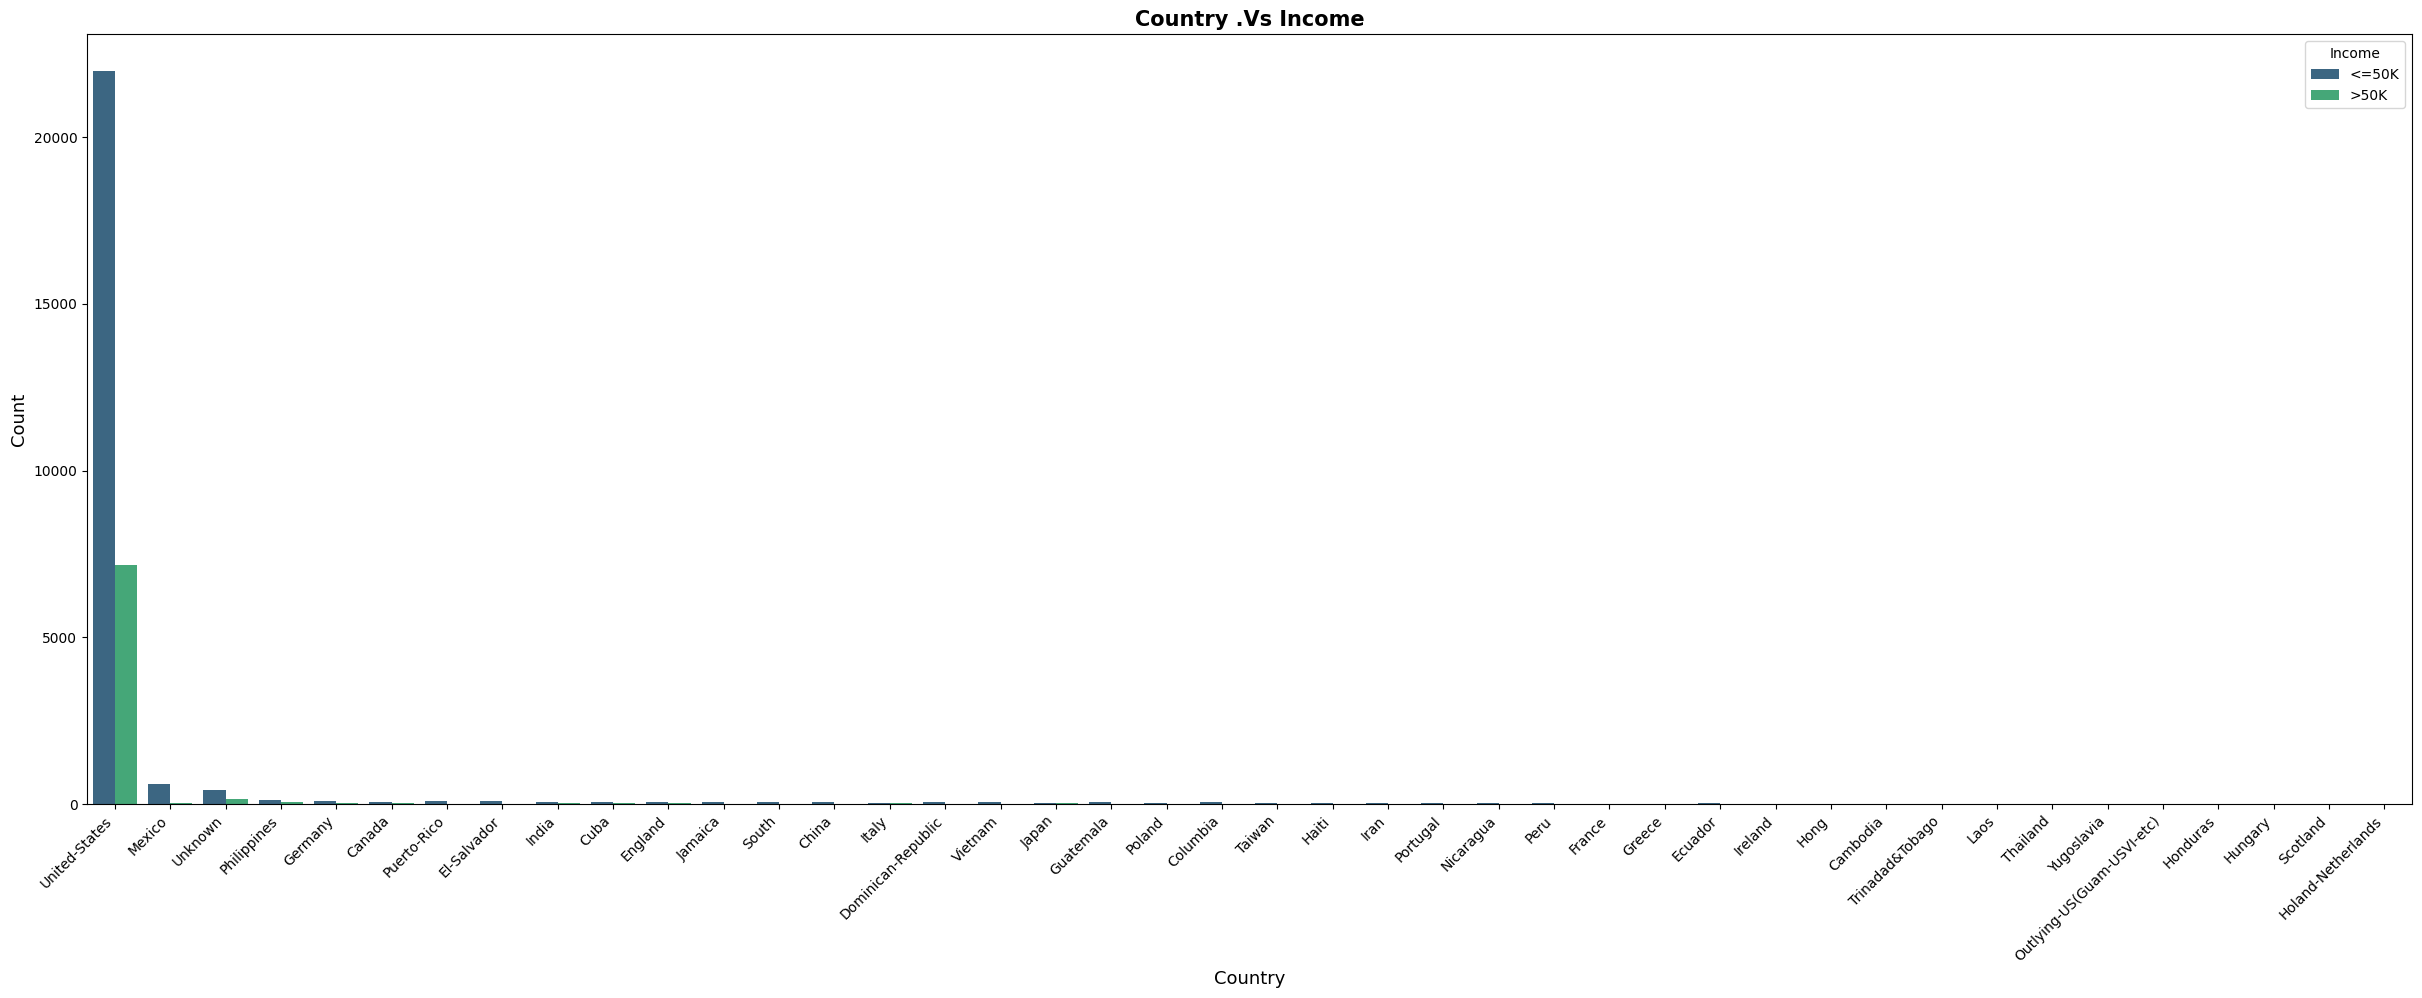

In [26]:
plt.figure(figsize=(30,10))
ordered = Adult_Data['native_country'].value_counts().index
sns.countplot(x='native_country', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='viridis')
plt.xlabel('Country', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.title('Country .Vs Income', weight='bold', fontsize=15)
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

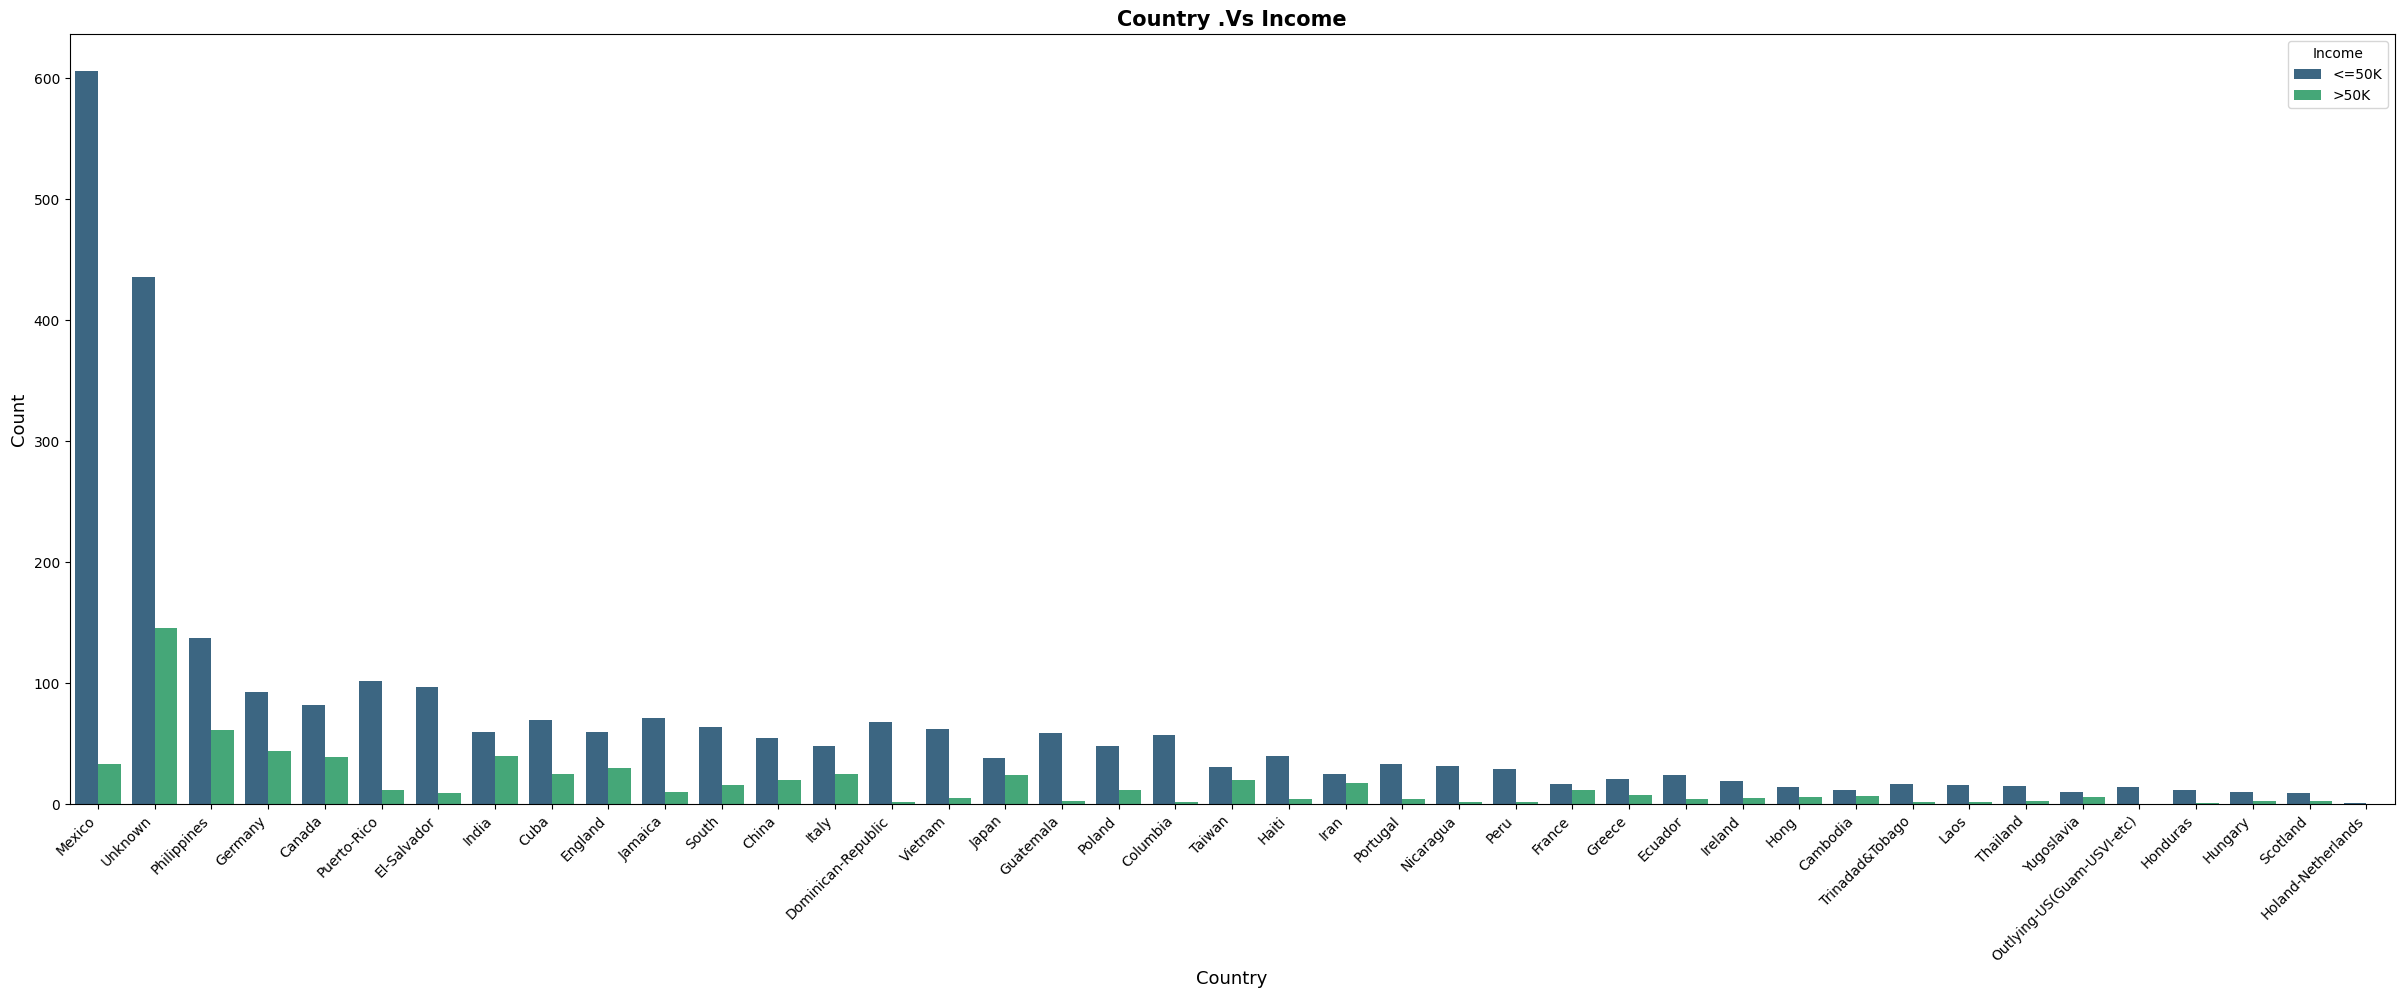

In [27]:
plt.figure(figsize=(30,10))
Filt_Country_Adult_Data = Adult_Data[Adult_Data['native_country'] != (Adult_Data['native_country'].value_counts().idxmax())]
ordered = Filt_Country_Adult_Data['native_country'].value_counts().index
P = sns.countplot(x='native_country', data=Filt_Country_Adult_Data, hue='Income', legend=True, order=ordered, palette='viridis')
    
plt.xlabel('Country', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.title('Country .Vs Income', weight='bold', fontsize=15)
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## Marital Status Exploration

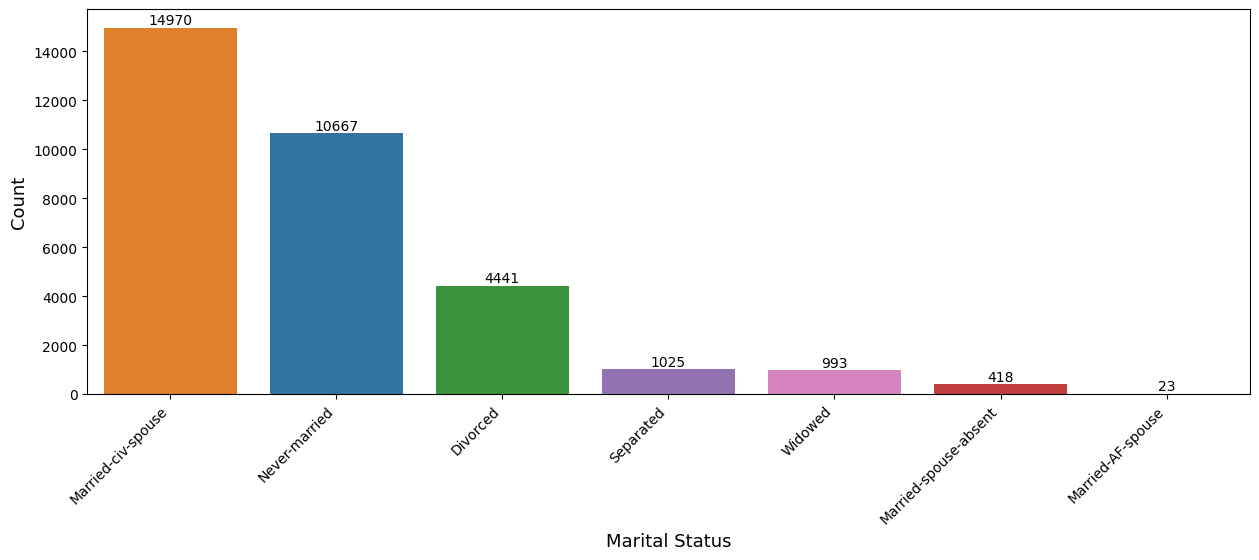

In [28]:
plt.figure(figsize=(15,5))
ordered = Adult_Data['marital_status'].value_counts().index
P = sns.countplot(x='marital_status', data=Adult_Data, hue='marital_status', legend=False, order=ordered)
plt.xlabel('Marital Status', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

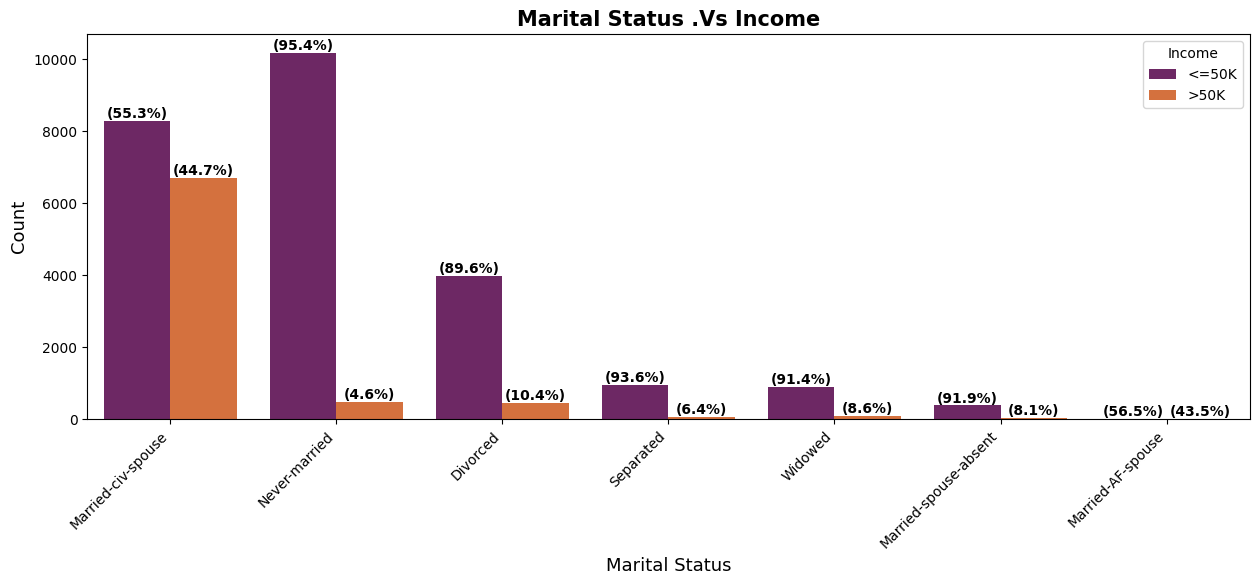

In [29]:
plt.figure(figsize=(15,5))
ordered = Adult_Data['marital_status'].value_counts().index
P = sns.countplot(x='marital_status', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='inferno')

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')

plt.title('Marital Status .Vs Income', weight='bold', fontsize=15)
plt.xlabel('Marital Status', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

##### As shown in the figure, Married-civ-spouse and Married-AF-spouse have a higher chance of earning more than 50K

## Relationship Exploration

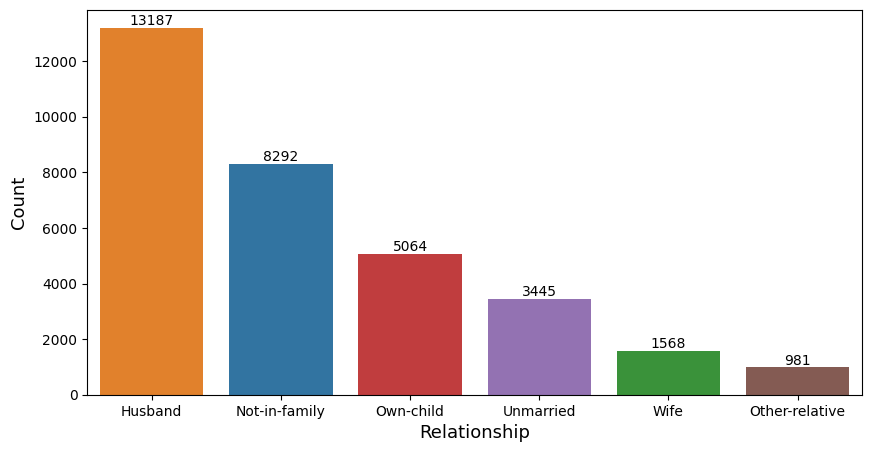

In [30]:
plt.figure(figsize=(10,5))
ordered = Adult_Data['relationship'].value_counts().index
P = sns.countplot(x='relationship', data=Adult_Data, hue='relationship', legend=False, order=ordered)
plt.xlabel('Relationship', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.show()

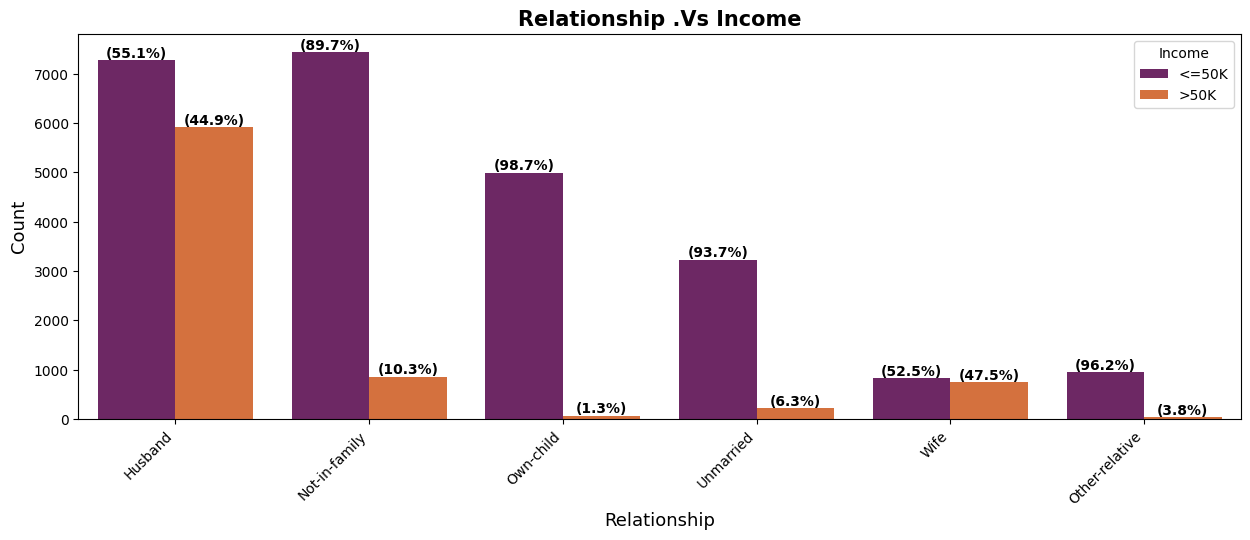

In [31]:
plt.figure(figsize=(15,5))
ordered = Adult_Data['relationship'].value_counts().index
P = sns.countplot(x='relationship', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='inferno')

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')

plt.title('Relationship .Vs Income', weight='bold', fontsize=15)
plt.xlabel('Relationship', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## Race Exploration

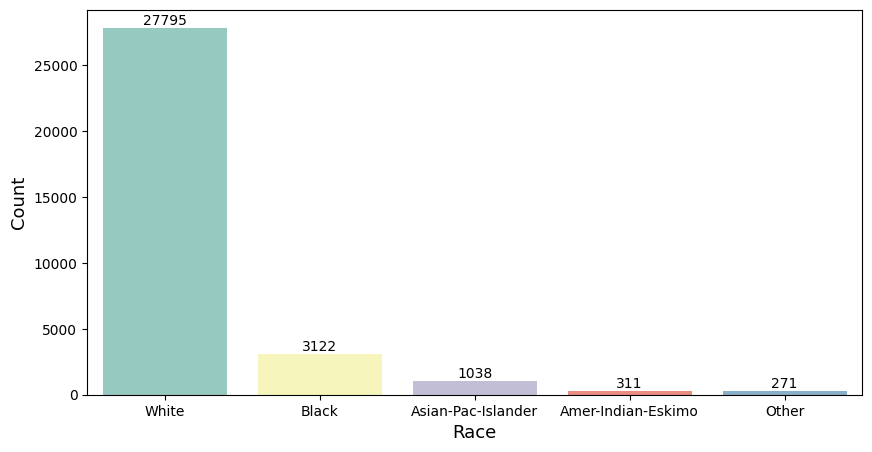

In [32]:
plt.figure(figsize=(10,5))
ordered = Adult_Data['race'].value_counts().index
P = sns.countplot(x='race', data=Adult_Data, hue='race', legend=False, order=ordered, palette='Set3')
plt.xlabel('Race', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.show()

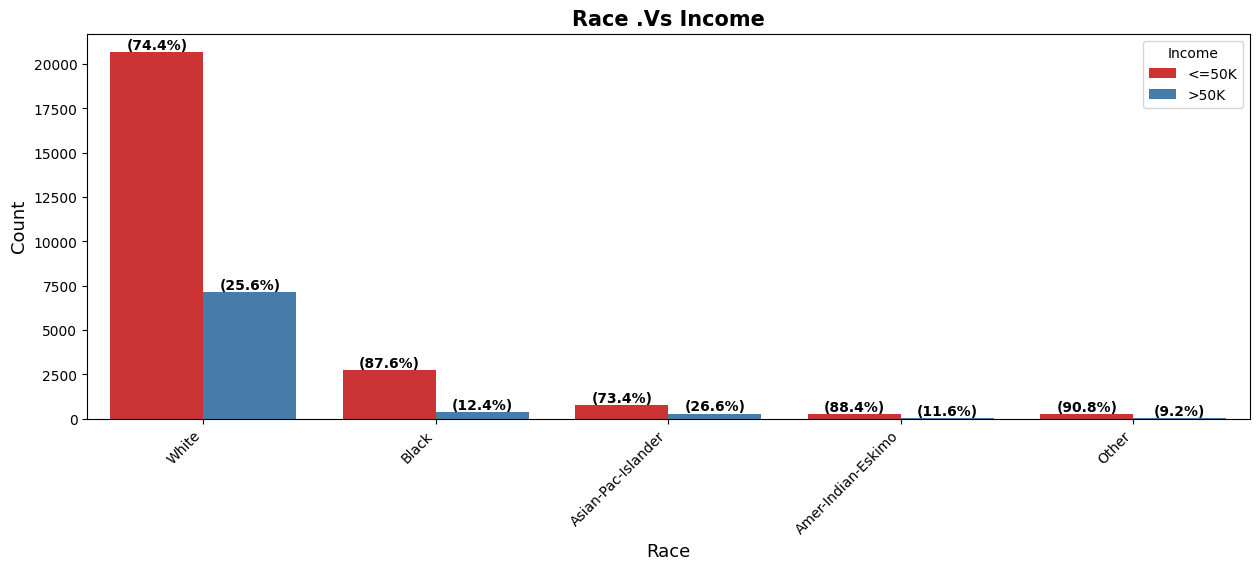

In [33]:
plt.figure(figsize=(15,5))
ordered = Adult_Data['race'].value_counts().index
P = sns.countplot(x='race', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='Set1')

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')

plt.title('Race .Vs Income', weight='bold', fontsize=15)
plt.xlabel('Race', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## Education Exploration

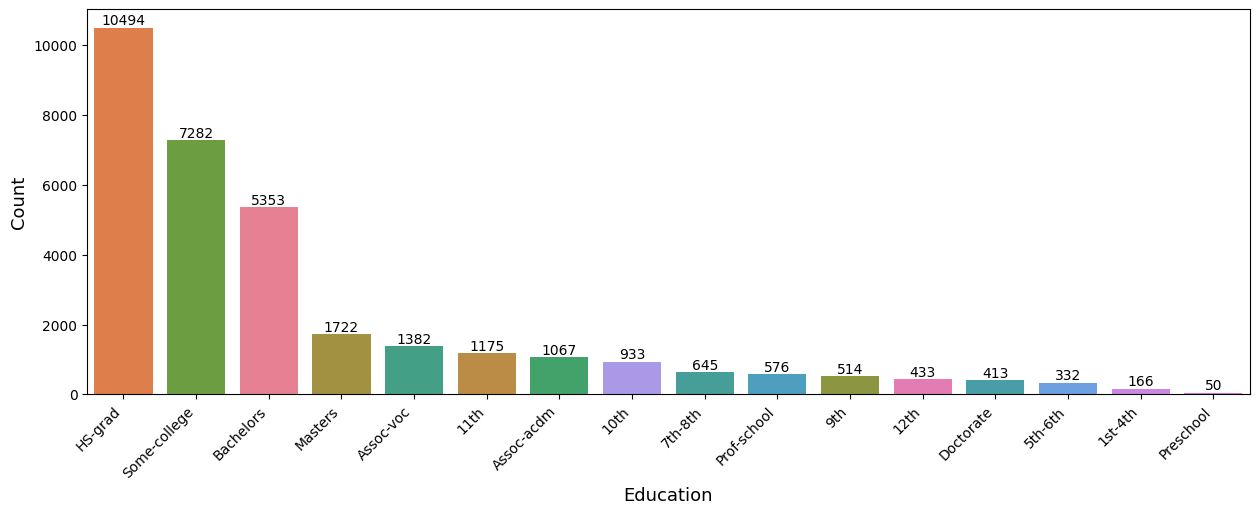

In [34]:
plt.figure(figsize=(15,5))
ordered = Adult_Data['education'].value_counts().index
P = sns.countplot(x='education', data=Adult_Data, hue='education', legend=False, order=ordered)
plt.xlabel('Education', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

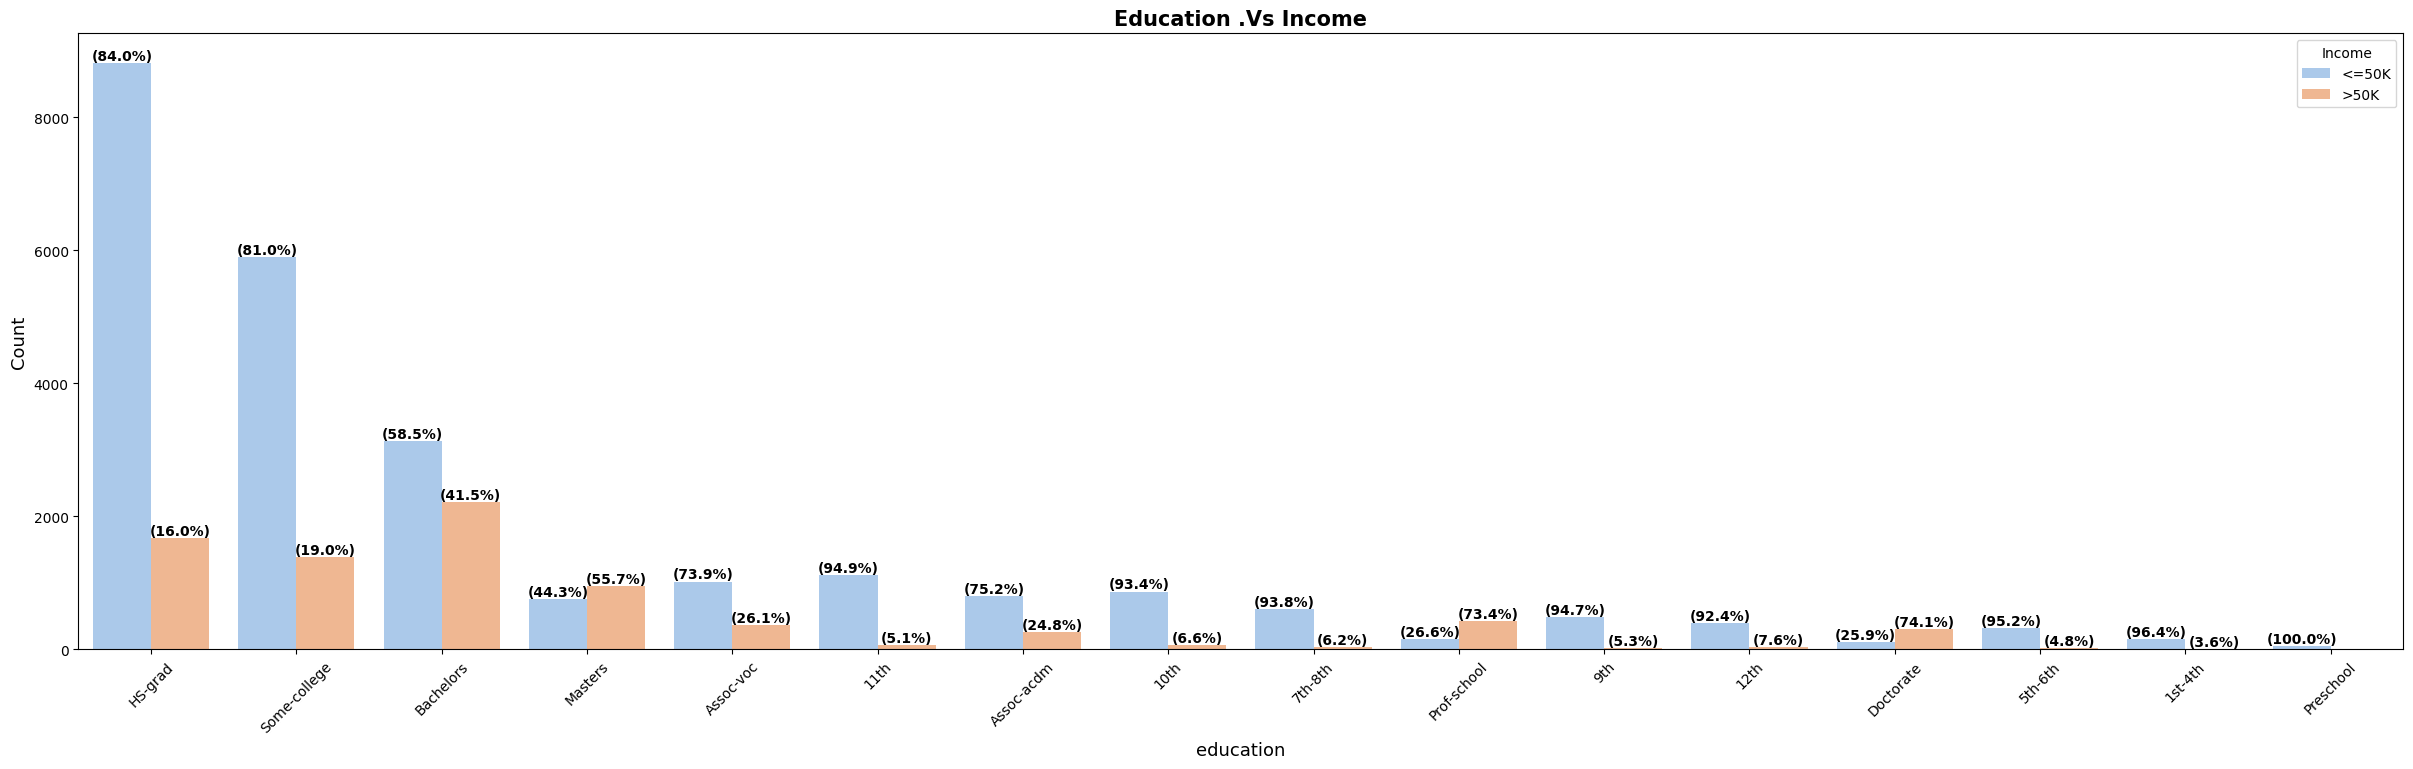

In [35]:
plt.figure(figsize=(30,8))
ordered = Adult_Data['education'].value_counts().index
P = sns.countplot(x='education', data=Adult_Data, hue='Income', legend=True, order=ordered, palette='pastel')

max_len = max(len(c.datavalues) for c in P.containers)
totals = np.zeros(max_len)

for container in P.containers:
    vals = np.zeros(max_len)
    vals[:len(container.datavalues)] = container.datavalues
    totals += vals

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')

plt.xlabel('education', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.title('Education .Vs Income', weight='bold', fontsize=15)
plt.xticks(rotation=45, fontsize=10)
plt.show()

##### As shown in the Education chart, Bachelors, Masters, Prof-schools, Doctorate, and overall higher education have a greater chance of earning more than 50K

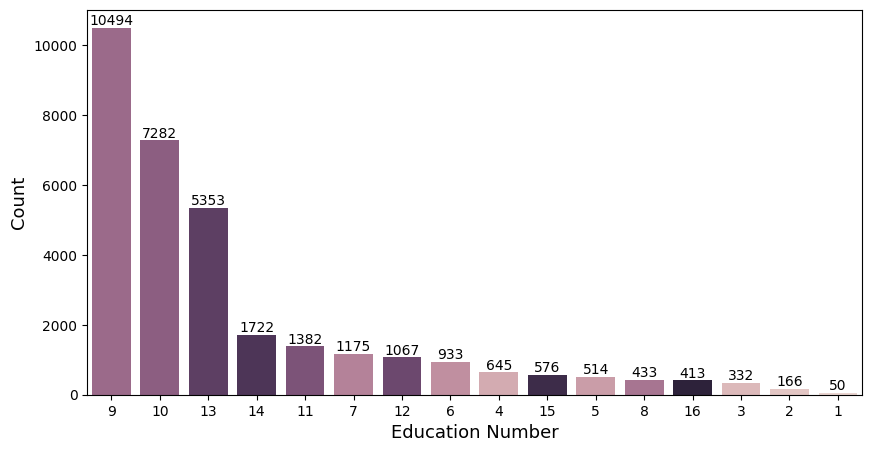

In [36]:
plt.figure(figsize=(10,5))
ordered = Adult_Data['education_num'].value_counts().index
P = sns.countplot(x='education_num', data=Adult_Data, hue='education_num', legend=False, order=ordered)
plt.xlabel('Education Number', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.show()

## Gender Exploration

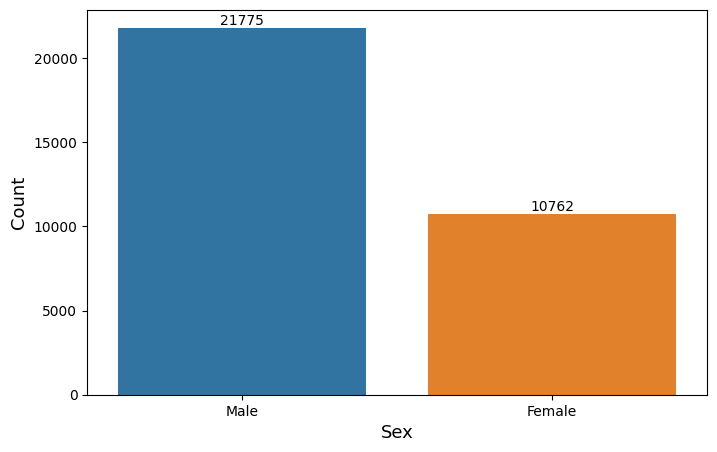

In [37]:
plt.figure(figsize=(8,5))
ordered = Adult_Data['sex'].value_counts().index
P = sns.countplot(x='sex', data=Adult_Data, hue='sex', legend=False, order=ordered)
plt.xlabel('Sex', fontsize=13)
plt.ylabel('Count',fontsize=13)
for p in P.patches:
    P.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xticks(fontsize=10)
plt.show()

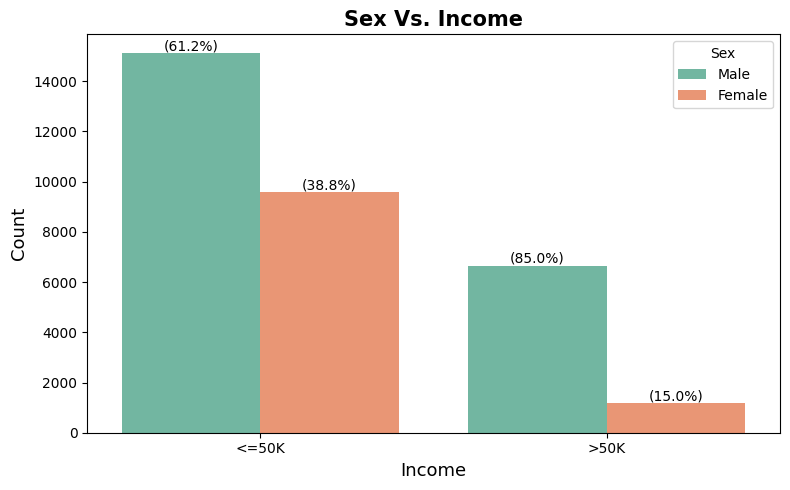

In [38]:
plt.figure(figsize=(8,5))
ordered = Adult_Data['Income'].value_counts().index
P = sns.countplot(x='Income', data=Adult_Data, hue='sex', order=ordered, palette='Set2')

male_heights = P.containers[0].datavalues
female_heights = P.containers[1].datavalues
totals = male_heights + female_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points')

plt.xlabel('Income', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=10)
plt.legend(title='Sex')
plt.title('Sex Vs. Income', weight='bold', fontsize=15)
plt.tight_layout()
plt.show()


##### As shown in the above figure, gender is correlated to income, and males have a higher chance of earning more than 50k

## Age Exploration

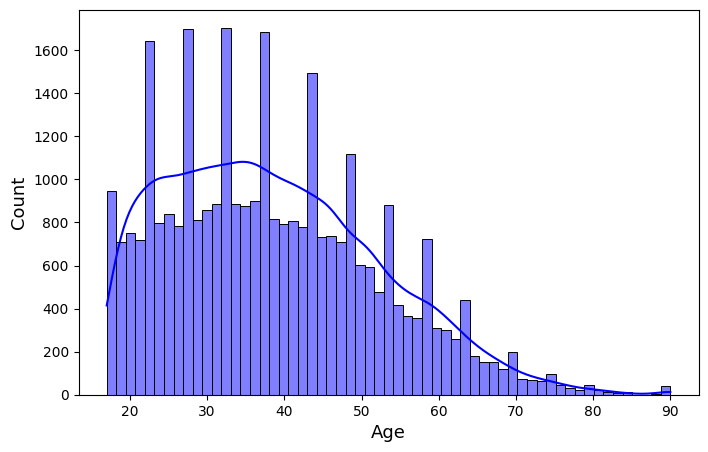

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(x='age', data=Adult_Data, kde=True, color='blue')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

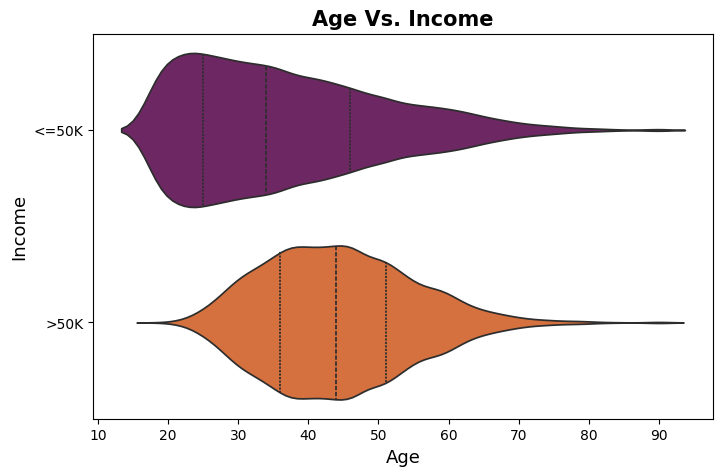

In [40]:
plt.figure(figsize=(8,5))
sns.violinplot(x='age', y='Income' ,data=Adult_Data, hue='Income', palette='inferno', inner='quart')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Income', fontsize=13)
plt.title('Age Vs. Income', weight='bold', fontsize=15)
plt.show()

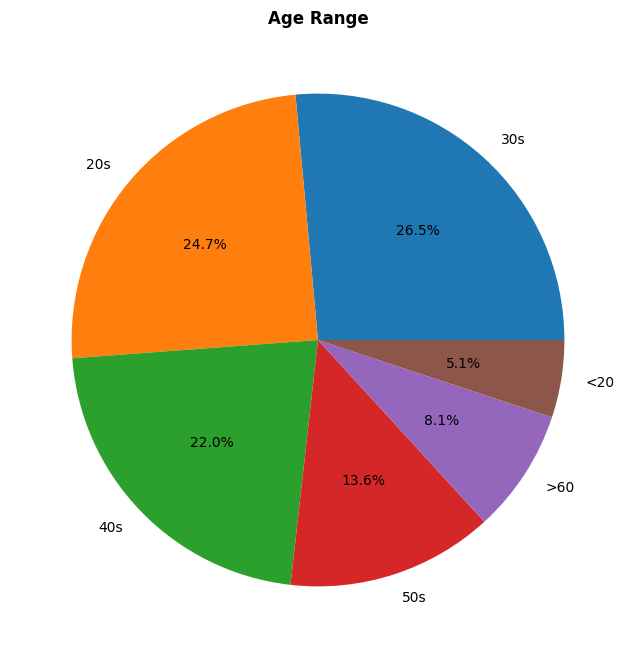

In [41]:
def age_range(age):
    
    if age < 20:
        age = '<20'
        return age
    elif (age >=20) & (age<30):
        age = '20s'
        return age
    elif (age >=30) & (age<40):
        age = '30s'
        return age
    elif (age >=40) & (age<50):
        age = '40s'
        return age
    elif (age >=50) & (age<60):
        age = '50s'
        return age
    else:
        age = '>60'
        return age

Range_Age = Adult_Data['age'].apply(age_range)

plt.figure(figsize=(8,8))
plt.pie(Range_Age.value_counts(), normalize=True, labels=Range_Age.value_counts().index, autopct='%1.1f%%', radius=1)
plt.title('Age Range', fontsize=12, weight='bold')
plt.show()

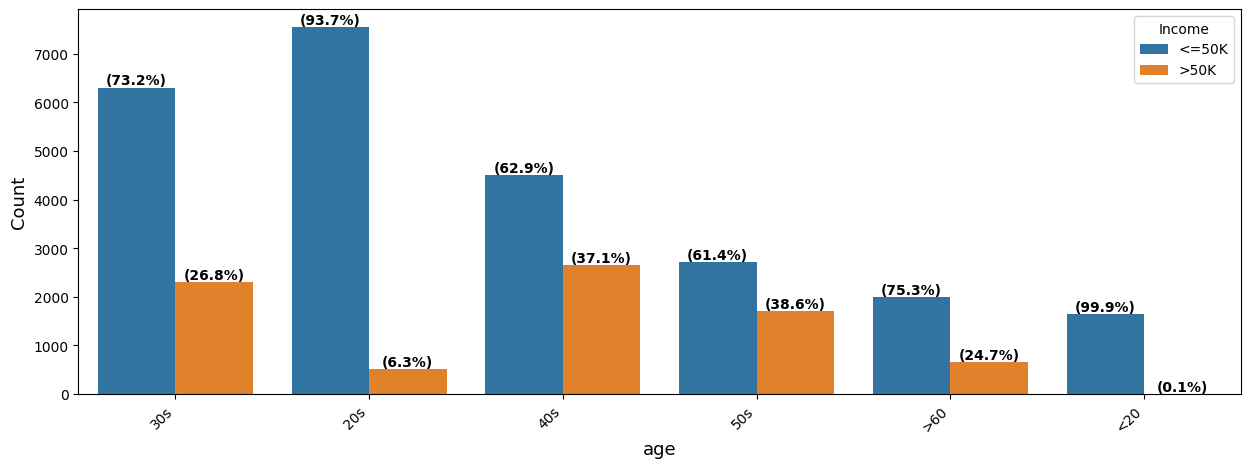

In [42]:
plt.figure(figsize=(15,5))
ordered = Range_Age.value_counts().index
P = sns.countplot(x=Range_Age, data=Adult_Data, hue='Income', legend=True, order=ordered)

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')
    
plt.xlabel('age', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

##### It can be seen that, at 40s and 50s, there is a greater chance of earning more than 50K

## Investimate Exploration

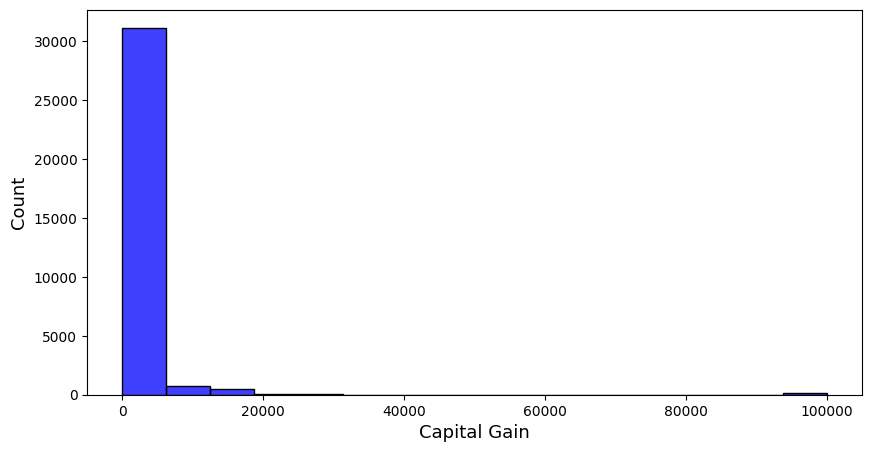

In [43]:
plt.figure(figsize=(10,5))
sns.histplot(x='capital_gain', data=Adult_Data, kde=False, color='blue')
plt.xlabel('Capital Gain', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

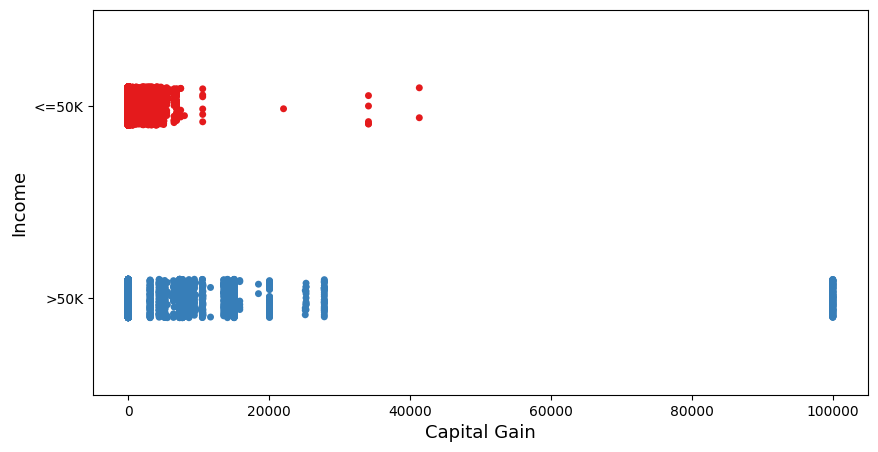

In [44]:
plt.figure(figsize=(10,5))
sns.stripplot(x='capital_gain', y='Income',data=Adult_Data,  hue='Income', palette='Set1')
plt.xlabel('Capital Gain', fontsize=13)
plt.ylabel('Income', fontsize=13)
plt.show()

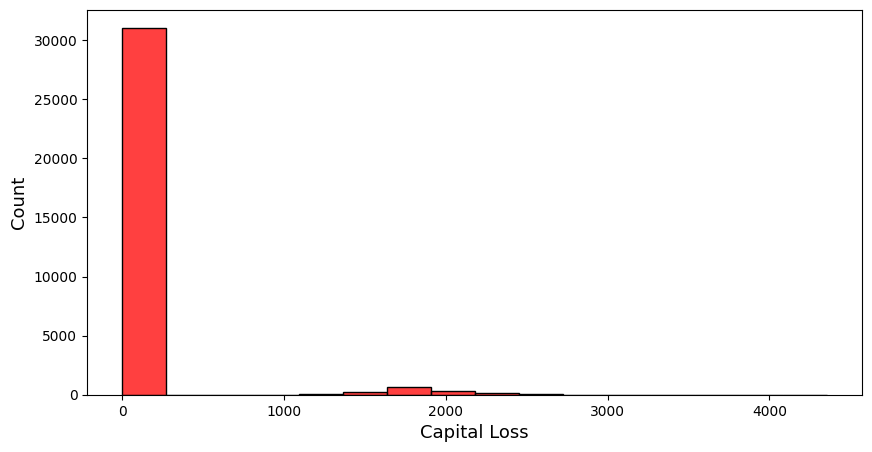

In [45]:
plt.figure(figsize=(10,5))
sns.histplot(x='capital_loss', data=Adult_Data, kde=False, color='red')
plt.xlabel('Capital Loss', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

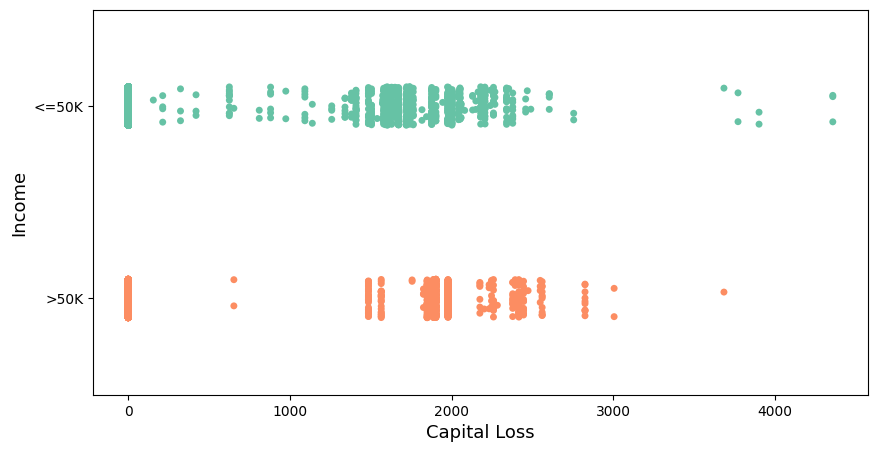

In [46]:
plt.figure(figsize=(10,5))
sns.stripplot(x='capital_loss', y='Income',data=Adult_Data,  hue='Income', palette='Set2')
plt.xlabel('Capital Loss', fontsize=13)
plt.ylabel('Income', fontsize=13)
plt.show()

## Working Hours Exploration

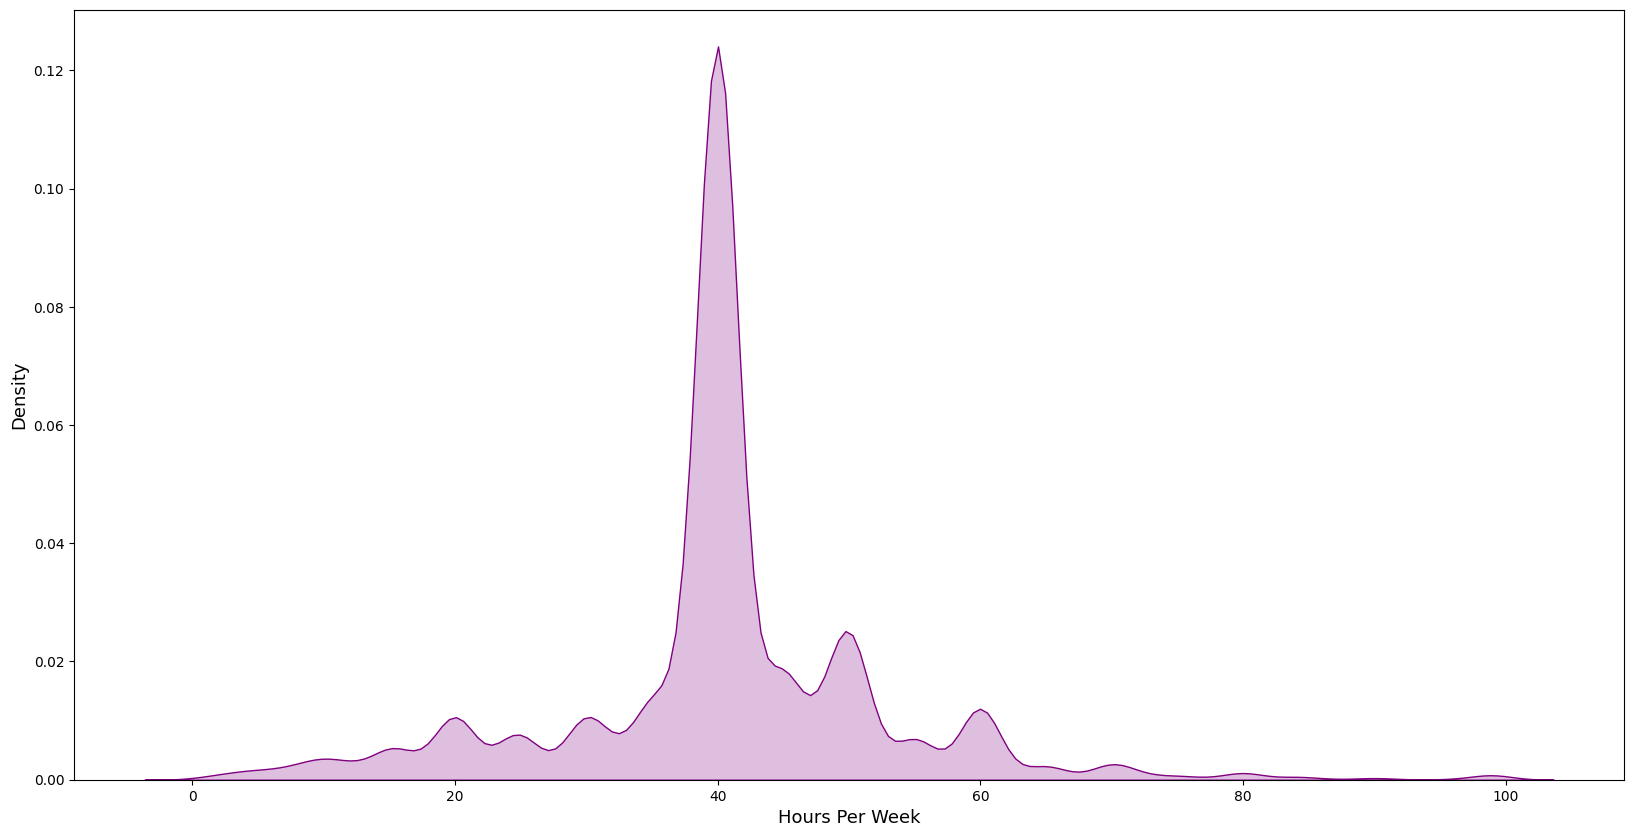

In [47]:
plt.figure(figsize=(20,10))
sns.kdeplot(x='hours_per_week', data=Adult_Data, fill=True, color='purple')
plt.xlabel('Hours Per Week', fontsize=13)
plt.ylabel('Density',fontsize=13)
plt.xticks(fontsize=10)
plt.show()

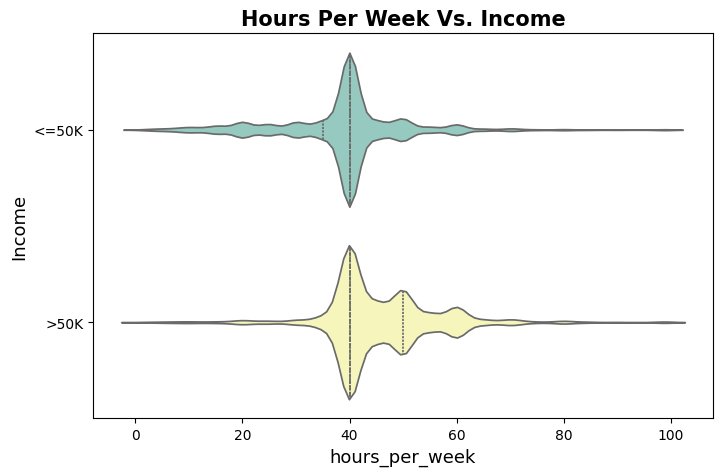

In [48]:
plt.figure(figsize=(8,5))
sns.violinplot(x='hours_per_week', y='Income' ,data=Adult_Data, hue='Income', palette='Set3', inner='quart', density_norm='width')
plt.xlabel('hours_per_week', fontsize=13)
plt.ylabel('Income', fontsize=13)
plt.title('Hours Per Week Vs. Income', weight='bold', fontsize=15)
plt.show()

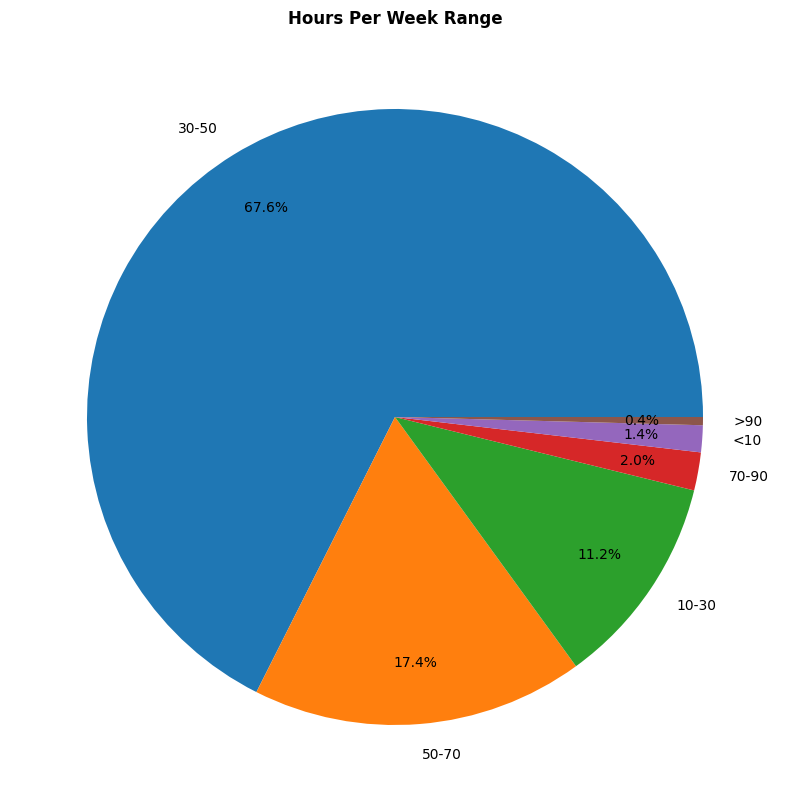

In [49]:
def HPW_range(h_p_w):
    
    if h_p_w < 10:
        h_p_w = '<10'
        return h_p_w
    elif (h_p_w >=10) & (h_p_w<30):
        h_p_w = '10-30'
        return h_p_w
    elif (h_p_w >=30) & (h_p_w<50):
        h_p_w = '30-50'
        return h_p_w
    elif (h_p_w >=50) & (h_p_w<70):
        h_p_w = '50-70'
        return h_p_w
    elif (h_p_w >=70) & (h_p_w<90):
        h_p_w = '70-90'
        return h_p_w
    else:
        h_p_w = '>90'
        return h_p_w
    

Range_HPW = Adult_Data['hours_per_week'].apply(HPW_range)

plt.figure(figsize=(10,10))
plt.pie(Range_HPW.value_counts(), normalize=True, labels=Range_HPW.value_counts().index, autopct='%1.1f%%', radius=1, pctdistance=0.8)
plt.title('Hours Per Week Range', fontsize=12, weight='bold')
plt.show()

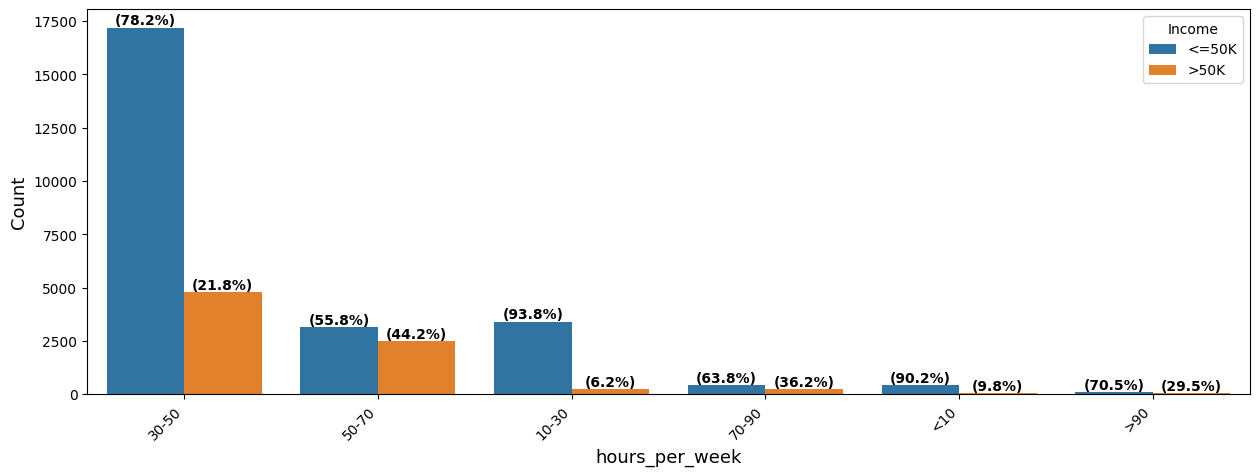

In [50]:
plt.figure(figsize=(15,5))
ordered = Range_HPW.value_counts().index
P = sns.countplot(x=Range_HPW, data=Adult_Data, hue='Income', legend=True, order=ordered)

First_heights = P.containers[0].datavalues
Second_heights = P.containers[1].datavalues
totals = First_heights + Second_heights

for i, hue_group in enumerate(P.containers):
    for j, p in enumerate(hue_group):
        height = p.get_height()
        percentage = (height / totals[j]) * 100
        P.annotate(f'({percentage:.1f}%)', 
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='center', xytext=(0, 5), 
                   textcoords='offset points', weight='bold')
    
plt.xlabel('hours_per_week', fontsize=13)
plt.ylabel('Count',fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

##### As shown in the figure, working between 50 and 70 hours a week leads to a higher chance of earning more than 50K

## fnlwgt Exploration

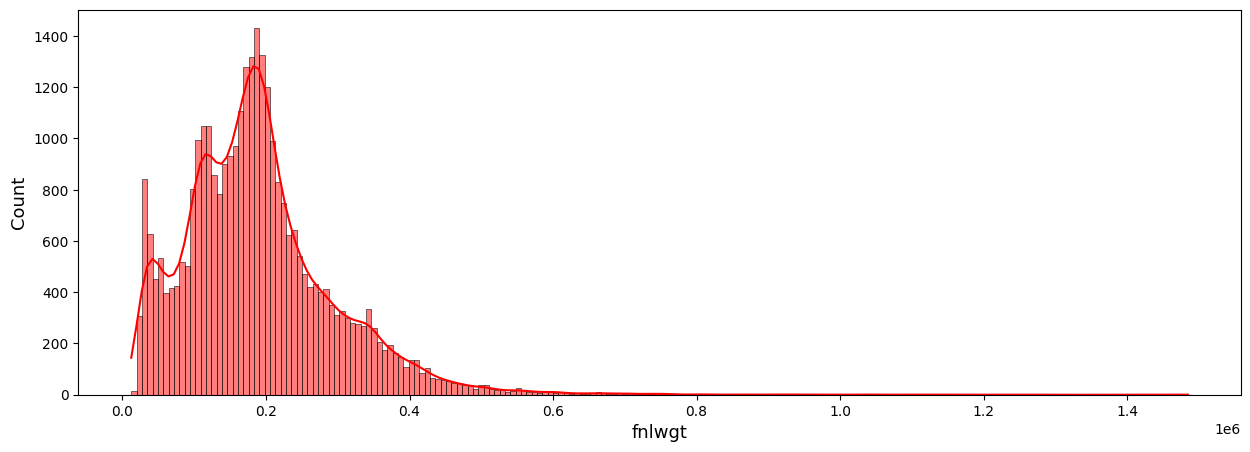

In [51]:
plt.figure(figsize=(15,5))
sns.histplot(x='fnlwgt', data=Adult_Data, kde=True, color='red')
plt.xlabel('fnlwgt', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

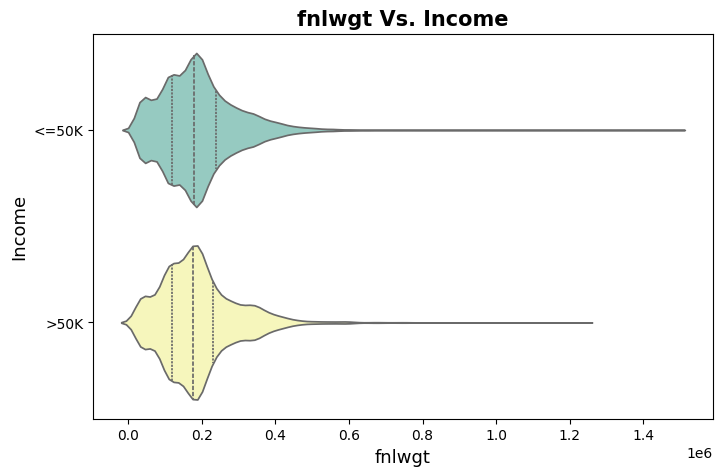

In [52]:
plt.figure(figsize=(8,5))
sns.violinplot(x='fnlwgt', y='Income' ,data=Adult_Data, hue='Income', palette='Set3', inner='quart')
plt.xlabel('fnlwgt', fontsize=13)
plt.ylabel('Income', fontsize=13)
plt.title('fnlwgt Vs. Income', weight='bold', fontsize=15)
plt.show()

# Feature Engineering

### Nationality (Country)

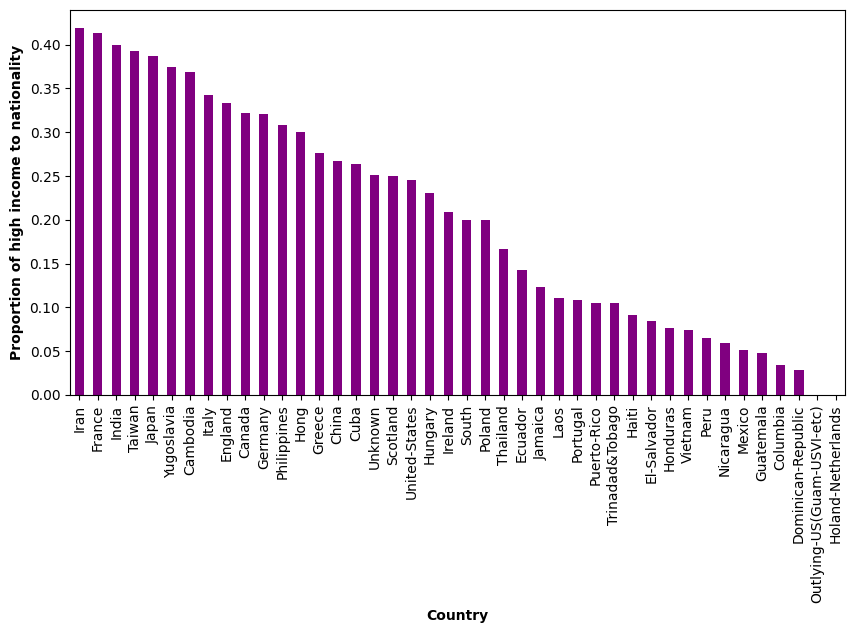

In [53]:
prop_highincome_nation = (Adult_Data.loc[Adult_Data['Income'] == '>50K','native_country'].value_counts()) /  (Adult_Data.loc[:,'native_country'].value_counts())
prop_highincome_nation.fillna(0, inplace=True)
prop_highincome_nation.sort_values(ascending=False).plot.bar(figsize=(10,5), color='purple')
plt.xlabel('Country', weight='bold')
plt.ylabel('Proportion of high income to nationality', weight='bold')
plt.show()

In [54]:
selected_nationality = prop_highincome_nation[prop_highincome_nation > 0.3].sort_values(ascending=False).index.to_list()
print('Selected Country Based Proportion of High Income:\n',selected_nationality)

Selected Country Based Proportion of High Income:
 ['Iran', 'France', 'India', 'Taiwan', 'Japan', 'Yugoslavia', 'Cambodia', 'Italy', 'England', 'Canada', 'Germany', 'Philippines']


In [55]:
Adult_Data['native_country'] = Adult_Data['native_country'].apply(lambda x: 'Level_1' if x in selected_nationality  
                                                                  else 'Level_2' if x not in  ['United-States','Mexico','Level_1']
                                                                  else x)

Adult_Test['native_country'] = Adult_Test['native_country'].apply(lambda x: 'Level_1' if x in selected_nationality  
                                                                  else 'Level_2' if x not in  ['United-States','Mexico','Level_1']
                                                                  else x)

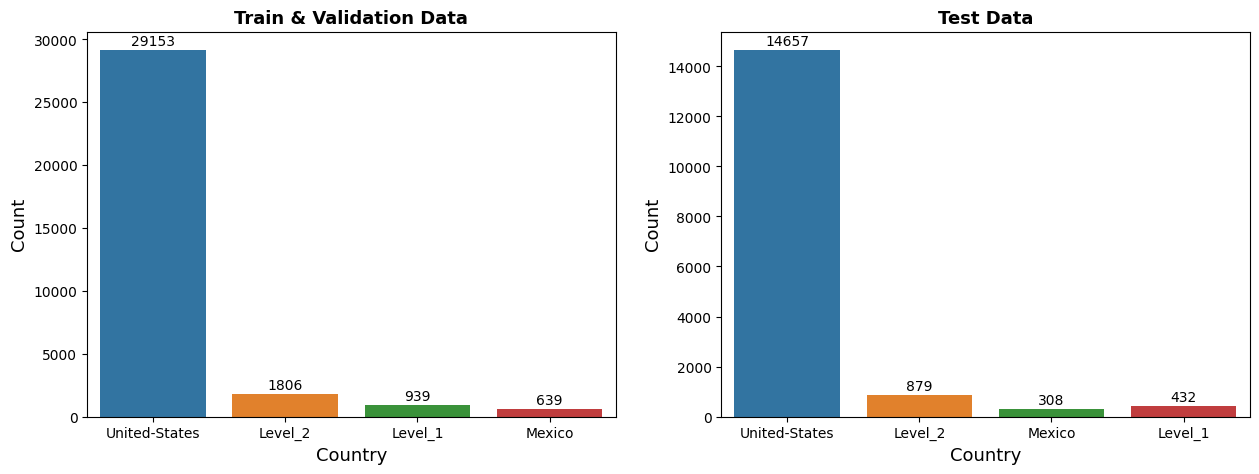

In [56]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

PTrain = sns.countplot(x='native_country', data=Adult_Data, hue='native_country', legend=False, ax=axes[0])
axes[0].set_xlabel('Country', fontsize=13)
axes[0].set_ylabel('Count',fontsize=13)
axes[0].set_title('Train & Validation Data', fontsize=13, weight='bold')
for p in PTrain.patches:
    PTrain.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10)
    
PTest = sns.countplot(x='native_country', data=Adult_Test, hue='native_country', legend=False, ax=axes[1])
axes[1].set_xlabel('Country', fontsize=13)
axes[1].set_ylabel('Count',fontsize=13)
axes[1].set_title('Test Data', fontsize=13, weight='bold')
for p in PTest.patches:
    PTest.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10)
    
plt.show()

## Work Class

In [57]:
Adult_Data['workclass'] = Adult_Data['workclass'].replace(['Without-pay','Never-worked','Unknown'],'Other')
Adult_Test['workclass'] = Adult_Test['workclass'].replace(['Without-pay','Never-worked','Unknown'],'Other')


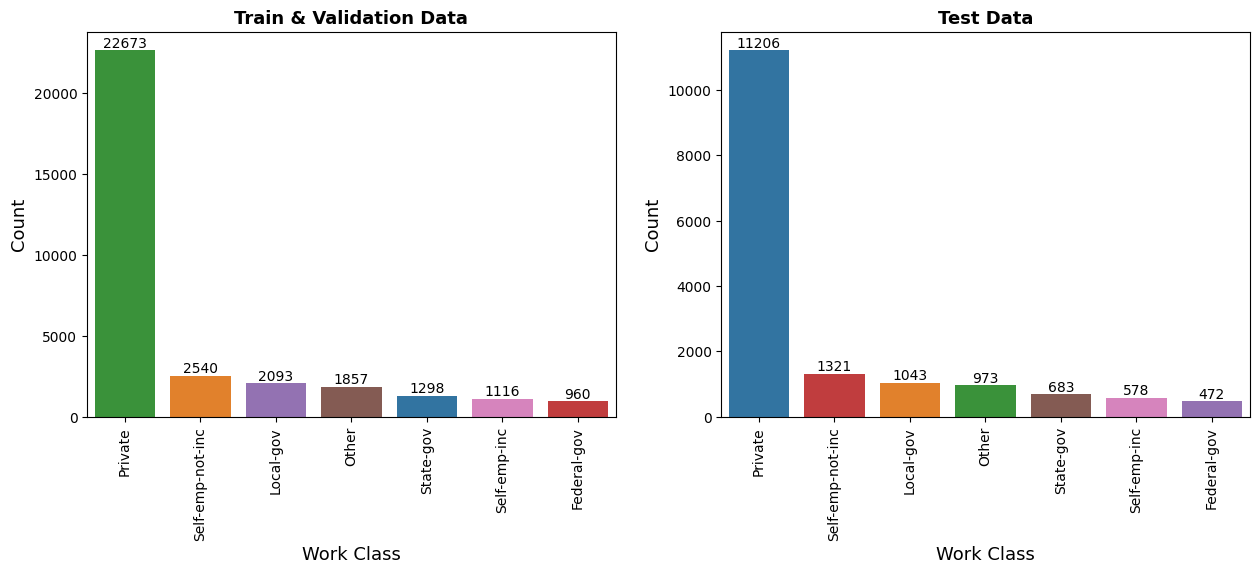

In [58]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

ordered_Train = Adult_Data['workclass'].value_counts().index
PTrain = sns.countplot(x='workclass', data=Adult_Data, hue='workclass', legend=False, order=ordered_Train, ax=axes[0])
axes[0].set_xlabel('Work Class', fontsize=13)
axes[0].set_ylabel('Count',fontsize=13)
axes[0].set_title('Train & Validation Data', fontsize=13, weight='bold')
for p in PTrain.patches:
    PTrain.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
axes[0].tick_params(axis='x', rotation=90)

ordered_Test = Adult_Data['workclass'].value_counts().index
PTest = sns.countplot(x='workclass', data=Adult_Test, hue='workclass', legend=False, order=ordered_Test, ax=axes[1])
axes[1].set_xlabel('Work Class', fontsize=13)
axes[1].set_ylabel('Count',fontsize=13)
axes[1].set_title('Test Data', fontsize=13, weight='bold')
for p in PTest.patches:
    PTest.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
axes[1].tick_params(axis='x', rotation=90)

plt.show()

## Education Number

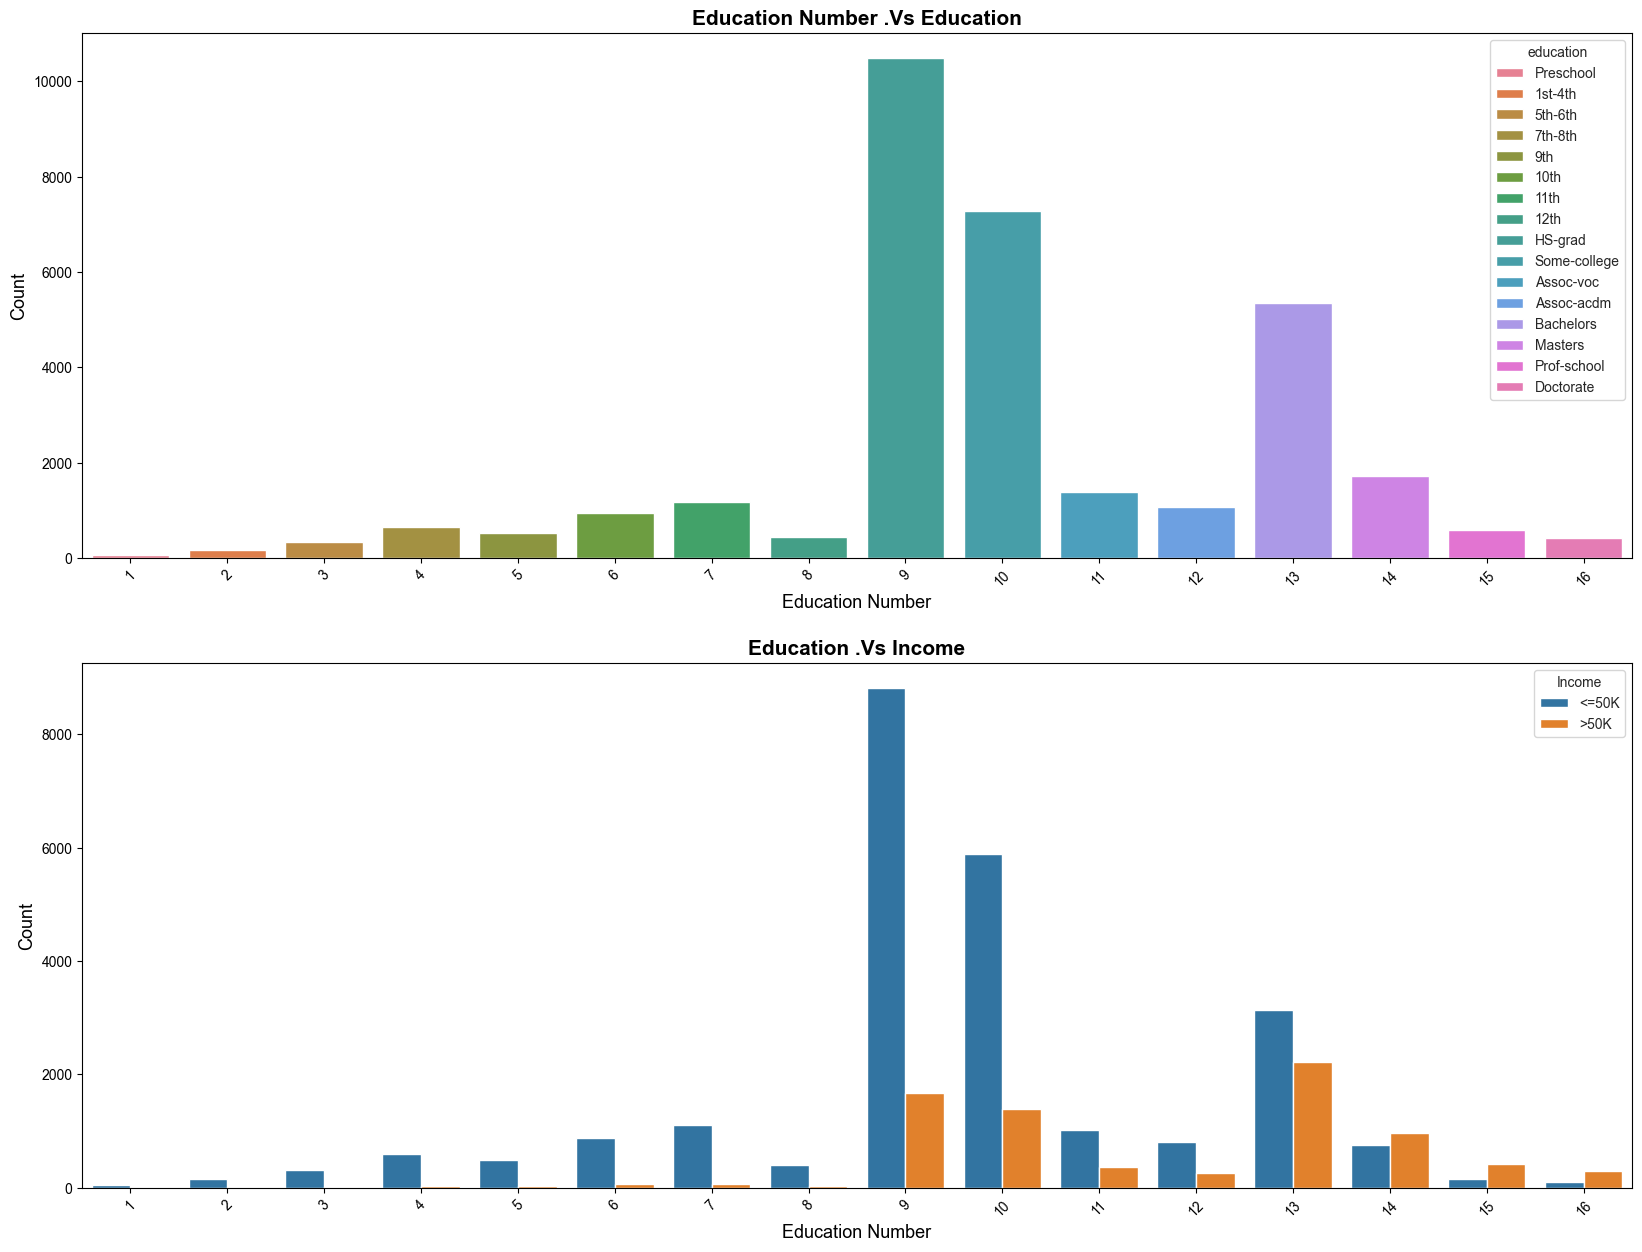

In [59]:

fig, axes = plt.subplots(2,1,figsize=(20,15))

sns.set_style("whitegrid")

sns.countplot(x='education_num', data=Adult_Data, hue='education', legend=True, ax=axes[0])
axes[0].set_xlabel('Education Number', fontsize=13)
axes[0].set_ylabel('Count',fontsize=13)
axes[0].set_title('Education Number .Vs Education', weight='bold', fontsize=15)
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='education_num', data=Adult_Data, hue='Income', legend=True, ax=axes[1])
axes[1].set_xlabel('Education Number', fontsize=13)
axes[1].set_ylabel('Count',fontsize=13)
axes[1].set_title('Education .Vs Income', weight='bold', fontsize=15)
axes[1].tick_params(axis='x', rotation=45)


In [60]:
Adult_Data['education_num'] = Adult_Data['education_num'].apply(lambda x: 1 if x in range(1,9) else x - 7)
Adult_Test['education_num'] = Adult_Test['education_num'].apply(lambda x: 1 if x in range(1,9) else x - 7)

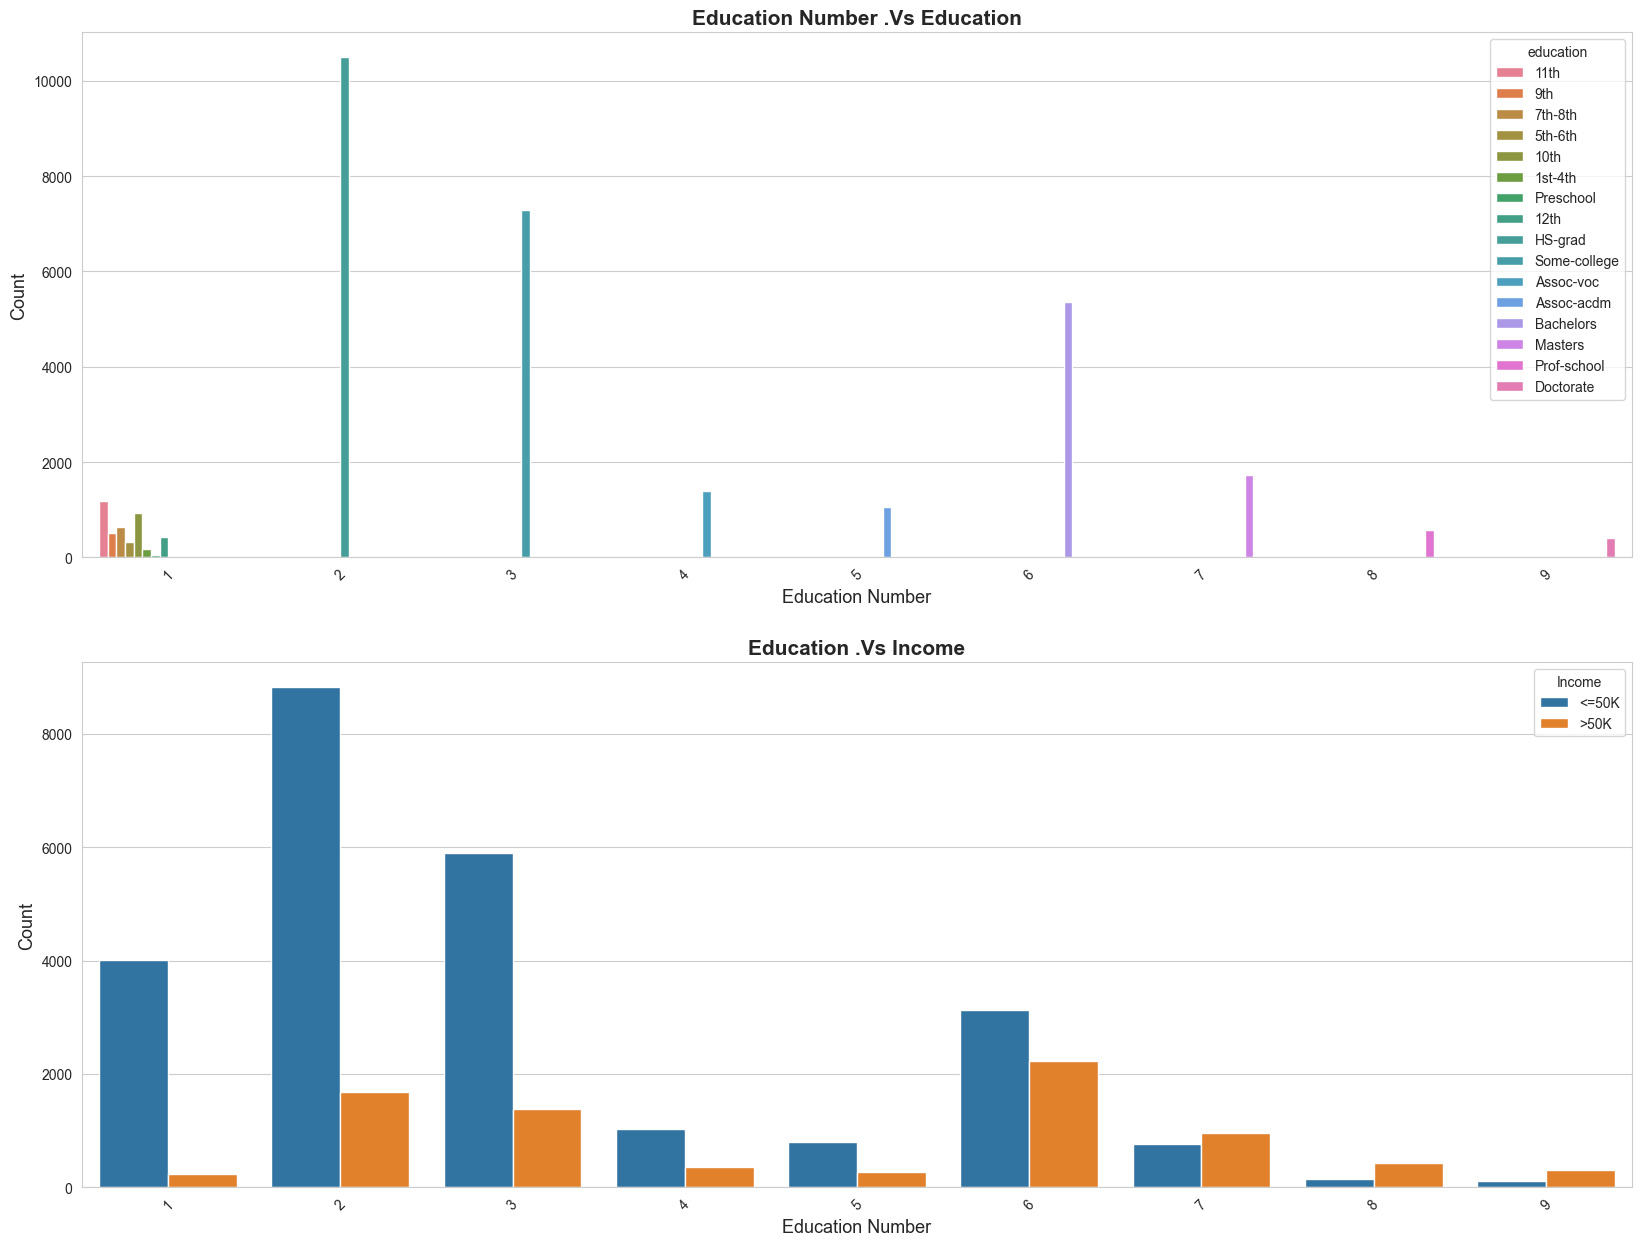

In [61]:
fig, axes = plt.subplots(2,1,figsize=(20,15))

sns.set_style("whitegrid")

sns.countplot(x='education_num', data=Adult_Data, hue='education', legend=True, ax=axes[0])
axes[0].set_xlabel('Education Number', fontsize=13)
axes[0].set_ylabel('Count',fontsize=13)
axes[0].set_title('Education Number .Vs Education', weight='bold', fontsize=15)
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='education_num', data=Adult_Data, hue='Income', legend=True, ax=axes[1])
axes[1].set_xlabel('Education Number', fontsize=13)
axes[1].set_ylabel('Count',fontsize=13)
axes[1].set_title('Education .Vs Income', weight='bold', fontsize=15)
axes[1].tick_params(axis='x', rotation=45)

## Capital

In [62]:
# Adult_Data['capital_gain_sign'] = Adult_Data['capital_gain'].apply(lambda x: 'has capital gain' if x > 0 else 'has not capital gain')

# Adult_Data['capital_loss_sign'] = np.where(Adult_Data['capital_loss'] > 0,'has capital loss','has not capital loss')

# Adult_Test['capital_gain_sign'] = Adult_Test['capital_gain'].apply(lambda x: 'has capital gain' if x > 0 else 'has not capital gain')

# Adult_Test['capital_loss_sign'] = np.where(Adult_Test['capital_loss'] > 0,'has capital loss','has not capital loss')

In [63]:
# plt.figure(figsize=(10,5))
# ordered = Adult_Data['capital_gain_sign'].value_counts().index
# P = sns.countplot(x='capital_gain_sign', data=Adult_Data, hue='Income', legend=True, order=ordered)

# First_heights = P.containers[0].datavalues
# Second_heights = P.containers[1].datavalues
# totals = First_heights + Second_heights

# for i, hue_group in enumerate(P.containers):
#     for j, p in enumerate(hue_group):
#         height = p.get_height()
#         percentage = (height / totals[j]) * 100
#         P.annotate(f'({percentage:.1f}%)', 
#                    (p.get_x() + p.get_width() / 2., height),
#                    ha='center', va='center', xytext=(0, 5), 
#                    textcoords='offset points', weight='bold')
    
# plt.xlabel('capital gain', fontsize=13)
# plt.ylabel('Count',fontsize=13)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.show()

In [64]:
# plt.figure(figsize=(10,5))
# ordered = Adult_Data['capital_loss_sign'].value_counts().index
# P = sns.countplot(x='capital_loss_sign', data=Adult_Data, hue='Income', legend=True, order=ordered)

# First_heights = P.containers[0].datavalues
# Second_heights = P.containers[1].datavalues
# totals = First_heights + Second_heights

# for i, hue_group in enumerate(P.containers):
#     for j, p in enumerate(hue_group):
#         height = p.get_height()
#         percentage = (height / totals[j]) * 100
#         P.annotate(f'({percentage:.1f}%)', 
#                    (p.get_x() + p.get_width() / 2., height),
#                    ha='center', va='center', xytext=(0, 5), 
#                    textcoords='offset points', weight='bold')
    
# plt.xlabel('capital loss', fontsize=13)
# plt.ylabel('Count',fontsize=13)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.show()

In [65]:
Adult_Data['log_capital_gain'] = np.round(np.log1p(Adult_Data['capital_gain']), decimals=2)
Adult_Data['log_capital_loss'] = np.round(np.log1p(Adult_Data['capital_loss']), decimals=2)

Adult_Test['log_capital_gain'] = np.round(np.log1p(Adult_Test['capital_gain']), decimals=2)
Adult_Test['log_capital_loss'] = np.round(np.log1p(Adult_Test['capital_loss']), decimals=2)

In [66]:
Adult_Data.drop('capital_gain', axis=1, inplace=True)
Adult_Data.drop('capital_loss', axis=1, inplace=True)

Adult_Test.drop('capital_gain', axis=1, inplace=True)
Adult_Test.drop('capital_loss', axis=1, inplace=True)

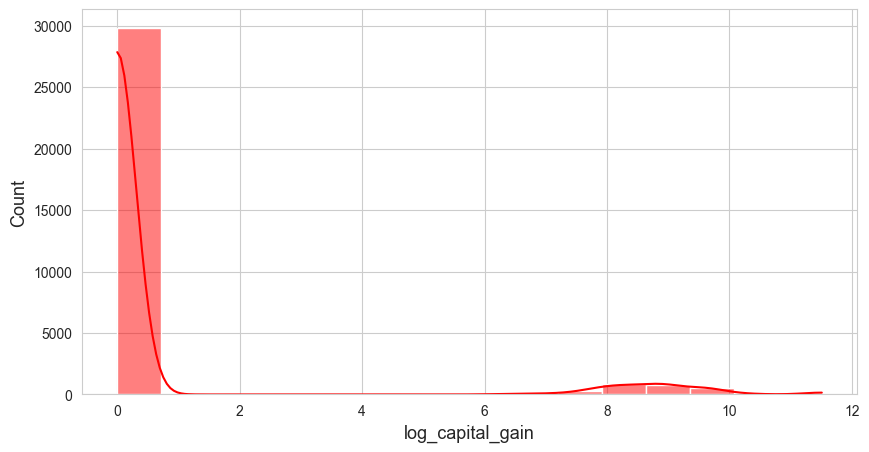

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(x='log_capital_gain', data=Adult_Data, kde=True, color='red')
plt.xlabel('log_capital_gain', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

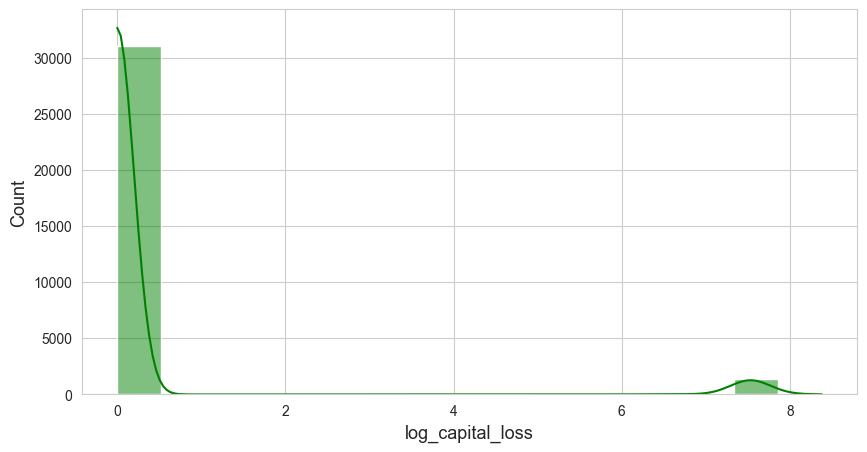

In [68]:
plt.figure(figsize=(10,5))
sns.histplot(x='log_capital_loss', data=Adult_Data, kde=True, color='green')
plt.xlabel('log_capital_loss', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

## fnlwgt

In [69]:
# Adult_Data['log_fnlwgt'] = np.round(np.log1p(Adult_Data['fnlwgt']), decimals=3)
# Adult_Test['log_fnlwgt'] = np.round(np.log1p(Adult_Test['fnlwgt']), decimals=3)
# plt.figure(figsize=(15,5))
# sns.histplot(x='log_fnlwgt', data=Adult_Data, kde=True, color='red')
# plt.xlabel('log_fnlwgt', fontsize=13)
# plt.ylabel('Count', fontsize=13)
# plt.show()

In [70]:
Adult_Data['race'] = Adult_Data['race'].apply(lambda x: 'Other' if x in ['Amer-Indian-Eskimo','Black','Other'] else x)
Adult_Test['race'] = Adult_Test['race'].apply(lambda x: 'Other' if x in ['Amer-Indian-Eskimo','Black','Other'] else x)

Adult_Data['occupation'] = Adult_Data['occupation'].apply(lambda x: 'Other' if x in ['Other-service','Handlers-cleaners','Priv-house-serv','Unknown','Farming-fishing'
                                                                                     ,'Armed-Forces','Adm-clerical'] else x)
Adult_Test['occupation'] = Adult_Test['occupation'].apply(lambda x: 'Other' if x in ['Other-service','Handlers-cleaners','Priv-house-serv','Unknown','Farming-fishing'
                                                                                     ,'Armed-Forces','Adm-clerical'] else x)

Adult_Data['marital_status'] = Adult_Data['marital_status'].apply(lambda x: 'Married' if x in ['Married-AF-spouse','Married-civ-spouse'] else 'Other')
Adult_Test['marital_status'] = Adult_Test['marital_status'].apply(lambda x: 'Married' if x in ['Married-AF-spouse','Married-civ-spouse'] else 'Other')

Adult_Data['relationship'] = Adult_Data['relationship'].apply(lambda x: 'Family' if x in ['Husband', 'Wife'] else 'Other')
Adult_Test['relationship'] = Adult_Test['relationship'].apply(lambda x: 'Family' if x in ['Husband', 'Wife'] else 'Other')

In [71]:
Adult_Data.drop('fnlwgt', axis=1, inplace=True)
Adult_Test.drop('fnlwgt', axis=1, inplace=True)

Adult_Data = Adult_Data.drop('education', axis=1)
Adult_Test = Adult_Test.drop('education', axis=1)

# Categorical To Numerical

In [72]:
Adult_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32537 non-null  int64  
 1   workclass         32537 non-null  object 
 2   education_num     32537 non-null  int64  
 3   marital_status    32537 non-null  object 
 4   occupation        32537 non-null  object 
 5   relationship      32537 non-null  object 
 6   race              32537 non-null  object 
 7   sex               32537 non-null  object 
 8   hours_per_week    32537 non-null  int64  
 9   native_country    32537 non-null  object 
 10  Income            32537 non-null  object 
 11  log_capital_gain  32537 non-null  float64
 12  log_capital_loss  32537 non-null  float64
dtypes: float64(2), int64(3), object(8)
memory usage: 3.2+ MB


In [73]:
print('Numerical Features:\n{}\n'.format(Adult_Data.select_dtypes(['int','float64']).columns.to_list()))
print('Categorical Features:\n{}'.format(Adult_Data.select_dtypes('object').columns.to_list()))

Numerical Features:
['age', 'education_num', 'hours_per_week', 'log_capital_gain', 'log_capital_loss']

Categorical Features:
['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'Income']


In [74]:
disc_conti_features = Adult_Data.select_dtypes(include=['int','float64']).columns.to_list()
disc_conti_features

['age',
 'education_num',
 'hours_per_week',
 'log_capital_gain',
 'log_capital_loss']

In [75]:
Nominal_Feature = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Ordinal_Feature = ['education_num', 'sex', 'Income']

In [76]:
Adult_Data

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,Income,log_capital_gain,log_capital_loss
0,39,State-gov,6,Other,Other,Other,White,Male,40,United-States,<=50K,7.68,0.0
1,50,Self-emp-not-inc,6,Married,Exec-managerial,Family,White,Male,13,United-States,<=50K,0.00,0.0
2,38,Private,2,Other,Other,Other,White,Male,40,United-States,<=50K,0.00,0.0
3,53,Private,1,Married,Other,Family,Other,Male,40,United-States,<=50K,0.00,0.0
4,28,Private,6,Married,Prof-specialty,Family,Other,Female,40,Level_2,<=50K,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,Private,5,Married,Tech-support,Family,White,Female,38,United-States,<=50K,0.00,0.0
32533,40,Private,2,Married,Machine-op-inspct,Family,White,Male,40,United-States,>50K,0.00,0.0
32534,58,Private,2,Other,Other,Other,White,Female,40,United-States,<=50K,0.00,0.0
32535,22,Private,2,Other,Other,Other,White,Male,20,United-States,<=50K,0.00,0.0


In [77]:
Adult_Test

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,Income,log_capital_gain,log_capital_loss
0,25,Private,1,Other,Machine-op-inspct,Other,Other,Male,40,United-States,<=50K,0.00,0.0
1,38,Private,2,Married,Other,Family,White,Male,50,United-States,<=50K,0.00,0.0
2,28,Local-gov,5,Married,Protective-serv,Family,White,Male,40,United-States,>50K,0.00,0.0
3,44,Private,3,Married,Machine-op-inspct,Family,Other,Male,40,United-States,>50K,8.95,0.0
4,18,Other,3,Other,Other,Other,White,Female,30,United-States,<=50K,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16271,39,Private,6,Other,Prof-specialty,Other,White,Female,36,United-States,<=50K,0.00,0.0
16272,64,Other,2,Other,Other,Other,Other,Male,40,United-States,<=50K,0.00,0.0
16273,38,Private,6,Married,Prof-specialty,Family,White,Male,50,United-States,<=50K,0.00,0.0
16274,44,Private,6,Other,Other,Other,Asian-Pac-Islander,Male,40,United-States,<=50K,8.60,0.0


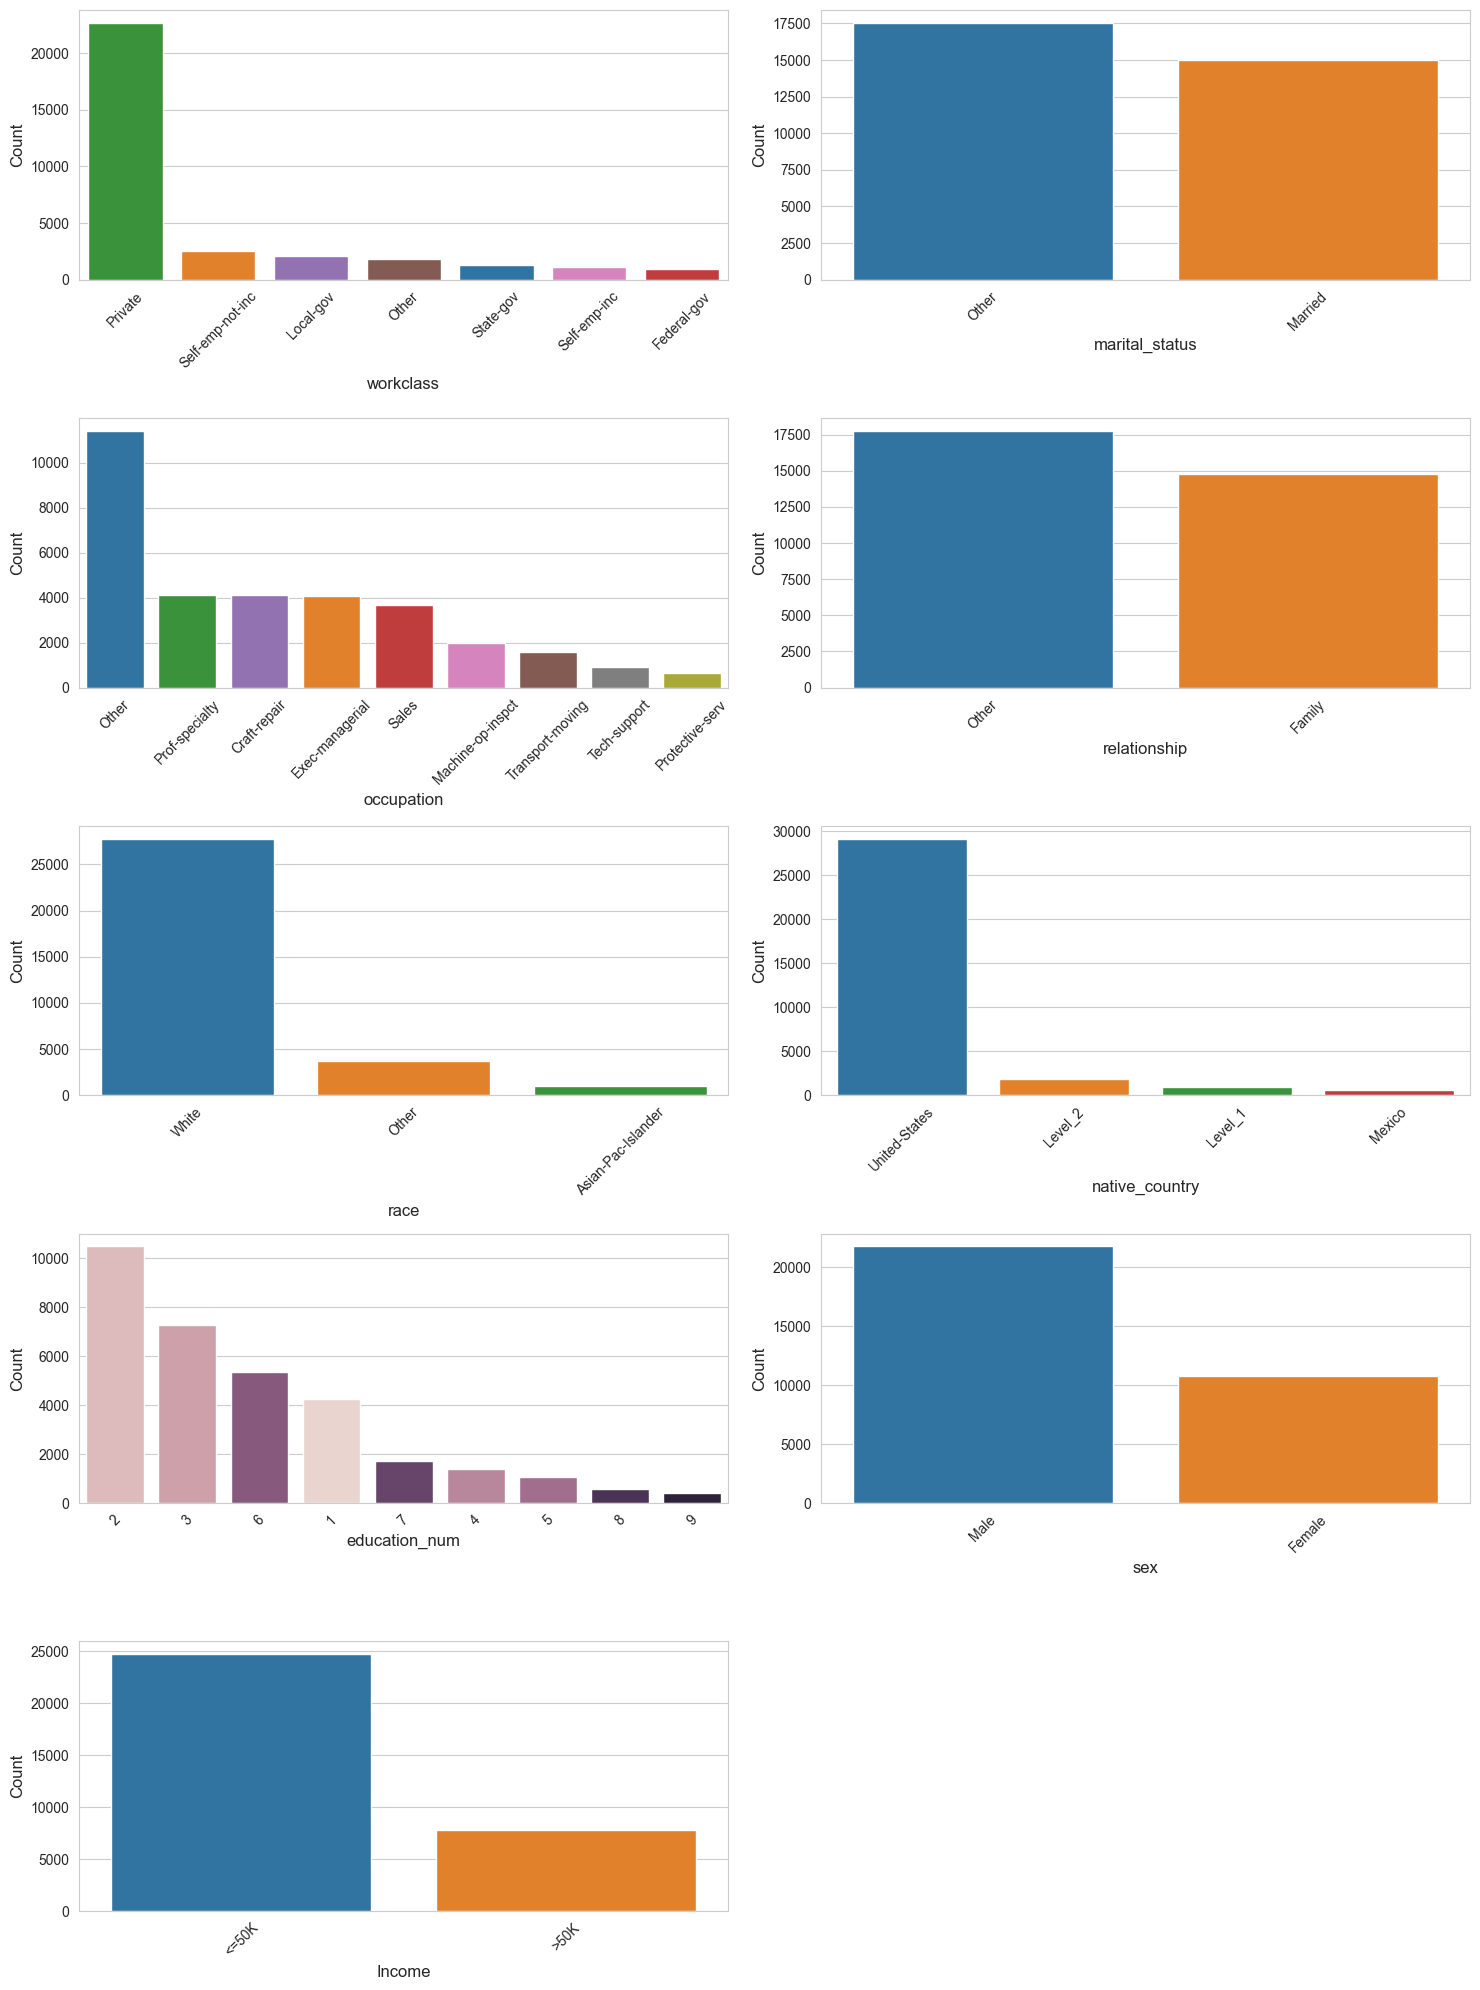

In [78]:
fig, axes = plt.subplots(5,2, figsize=(15,20))
ax = axes.flatten()

sns.set_style('whitegrid')

for i, feature in enumerate(Nominal_Feature + Ordinal_Feature):
    ordered = Adult_Data[feature].value_counts().index
    sns.countplot(x=feature, data=Adult_Data, hue=feature, legend=False, order=ordered, ax=ax[i])
    ax[i].set_xlabel(feature, fontsize=12)
    ax[i].set_ylabel('Count',fontsize=12)
    ax[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.delaxes(ax[9])
                    
            

### Resampling

### SMOTE

In [79]:
ohe_smote = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')

In [80]:
AdultData_SMOTE = Adult_Data.copy()

minmax_SMOTE = MinMaxScaler()
AdultData_SMOTE[['age','hours_per_week','log_capital_gain','log_capital_loss']] = minmax_SMOTE.fit_transform(AdultData_SMOTE[['age','hours_per_week','log_capital_gain','log_capital_loss']]) 

SMOTE_Method = SMOTENC(sampling_strategy=0.5, k_neighbors = 5, random_state=42, categorical_encoder = ohe_smote,
                       categorical_features = [AdultData_SMOTE.drop(['Income'], axis=1).columns.get_loc(x) for x in AdultData_SMOTE.drop(['Income'], axis=1).columns 
                                               if x not in disc_conti_features or x=='education_num'])

X_train_SMOTE, Y_train_SMOTE = SMOTE_Method.fit_resample(AdultData_SMOTE.drop('Income', axis=1), AdultData_SMOTE['Income'])

X_train_SMOTE[['age','hours_per_week','log_capital_gain','log_capital_loss']] = np.round(minmax_SMOTE.inverse_transform(X_train_SMOTE[['age','hours_per_week','log_capital_gain','log_capital_loss']]))


### RandomlyOverSampling

In [81]:
AdultData_ROS = Adult_Data.copy()

minmax_ROS = MinMaxScaler()
AdultData_ROS[['age','hours_per_week','log_capital_gain','log_capital_loss']] = minmax_ROS.fit_transform(AdultData_ROS[['age','hours_per_week','log_capital_gain','log_capital_loss']]) 

ros = RandomOverSampler(sampling_strategy = 0.35, random_state = 42)

X_train_ROS, Y_train_ROS = ros.fit_resample(AdultData_ROS.drop('Income', axis=1), AdultData_ROS['Income'])

X_train_ROS[['age','hours_per_week','log_capital_gain','log_capital_loss']] = np.round(minmax_ROS.inverse_transform(X_train_ROS[['age','hours_per_week','log_capital_gain','log_capital_loss']]))


### One Hot Encoder

In [82]:
ohe_label_cols = []

for feature_name in Nominal_Feature:
    ohe = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')

    Train_Feature_Labels = ohe.fit_transform(Adult_Data[[feature_name]])
    df_Train_Feature_Labels = pd.DataFrame(Train_Feature_Labels, columns=ohe.get_feature_names_out([feature_name]))

    Test_Feature_Labels = ohe.transform(Adult_Test[[feature_name]])
    df_Test_Feature_Labels = pd.DataFrame(Test_Feature_Labels, columns=ohe.get_feature_names_out([feature_name]))

    ohe_label_cols.extend(ohe.get_feature_names_out([feature_name]))

    Adult_Data = pd.concat([Adult_Data.drop([feature_name], axis=1),df_Train_Feature_Labels], axis=1)
    Adult_Test = pd.concat([Adult_Test.drop([feature_name], axis=1),df_Test_Feature_Labels], axis=1)

    X_train_SMOTE = pd.concat([X_train_SMOTE.drop([feature_name], axis=1), pd.DataFrame(ohe.transform(X_train_SMOTE[[feature_name]]), columns=ohe.get_feature_names_out([feature_name]))], axis=1) 
    X_train_ROS = pd.concat([X_train_ROS.drop([feature_name], axis=1), pd.DataFrame(ohe.transform(X_train_ROS[[feature_name]]), columns=ohe.get_feature_names_out([feature_name]))], axis=1) 

print(f'Number of One Hot Encoder Columns: {len(ohe_label_cols)}')

Number of One Hot Encoder Columns: 27


In [83]:
sex_map = {'Female':0, 'Male':1}
Income_map = {'<=50K':0, '>50K':1}
# capital_gain_map = {'has not capital gain':0, 'has capital gain':1}
# capital_loss_map = {'has not capital loss':0, 'has capital loss':1}

Adult_Data['sex'] = Adult_Data['sex'].map(sex_map)
Adult_Data['Income'] = Adult_Data['Income'].map(Income_map)
X_train_SMOTE['sex'] = X_train_SMOTE['sex'].map(sex_map)
Y_train_SMOTE = Y_train_SMOTE.map(Income_map)
X_train_ROS['sex'] = X_train_ROS['sex'].map(sex_map)
Y_train_ROS = Y_train_ROS.map(Income_map)
# Adult_Data['capital_gain_sign'] = Adult_Data['capital_gain_sign'].map(capital_gain_map)
# Adult_Data['capital_loss_sign'] = Adult_Data['capital_loss_sign'].map(capital_loss_map)

Adult_Test['sex'] = Adult_Test['sex'].map(sex_map)
Adult_Test['Income'] = Adult_Test['Income'].map(Income_map)
# Adult_Test['capital_gain_sign'] = Adult_Test['capital_gain_sign'].map(capital_gain_map)
# Adult_Test['capital_loss_sign'] = Adult_Test['capital_loss_sign'].map(capital_loss_map)


### SMOTETomek

In [84]:
XData_Tomek = X_train_SMOTE.copy()
YData_Tomek = Y_train_SMOTE.copy()

minmax_Tomek = MinMaxScaler()
XData_Tomek[['age','hours_per_week','log_capital_gain','log_capital_loss']] = minmax_Tomek.fit_transform(XData_Tomek[['age','hours_per_week','log_capital_gain','log_capital_loss']]) 

tomek = TomekLinks(sampling_strategy = 'auto')
X_train_smotetomek, Y_train_smotetomek = tomek.fit_resample(XData_Tomek, YData_Tomek)

X_train_smotetomek[['age','hours_per_week','log_capital_gain','log_capital_loss']] = np.round(minmax_Tomek.inverse_transform(X_train_smotetomek[['age','hours_per_week','log_capital_gain','log_capital_loss']]))

In [85]:
print(f'Number of Samples : {Adult_Data.shape[0]}')
print(f'Number of Columns : {Adult_Data.shape[1]}')
print(f'Number of Test Samples : {Adult_Test.shape[0]}')
print(f'Number of Test Columns : {Adult_Test.shape[1]}')

Number of Samples : 32537
Number of Columns : 34
Number of Test Samples : 16276
Number of Test Columns : 34


In [86]:
Adult_Data

,age,education_num,sex,hours_per_week,Income,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
0,39,6,1,40,0,7.68,0.0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,50,6,1,13,0,0.00,0.0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
2,38,2,1,40,0,0.00,0.0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
3,53,1,1,40,0,0.00,0.0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
4,28,6,0,40,0,0.00,0.0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,5,0,38,0,0.00,0.0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
32533,40,2,1,40,1,0.00,0.0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
32534,58,2,0,40,0,0.00,0.0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
32535,22,2,1,20,0,0.00,0.0,0,0,0,...,0,0,1,0,0,1,0,0,0,1


In [87]:
Adult_Data = Adult_Data.drop('Income', axis=1).merge(Adult_Data['Income'], how='inner', left_index=True, right_index=True)
Adult_Data

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States,Income
0,39,6,1,40,7.68,0.0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,50,6,1,13,0.00,0.0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,38,2,1,40,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
3,53,1,1,40,0.00,0.0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
4,28,6,0,40,0.00,0.0,0,0,0,1,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,5,0,38,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
32533,40,2,1,40,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,1
32534,58,2,0,40,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
32535,22,2,1,20,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0


In [88]:
Adult_Test

,age,education_num,sex,hours_per_week,Income,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
0,25,1,1,40,0,0.00,0.0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
1,38,2,1,50,0,0.00,0.0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
2,28,5,1,40,1,0.00,0.0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
3,44,3,1,40,1,8.95,0.0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
4,18,3,0,30,0,0.00,0.0,0,0,1,...,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16271,39,6,0,36,0,0.00,0.0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
16272,64,2,1,40,0,0.00,0.0,0,0,1,...,0,0,1,0,1,0,0,0,0,1
16273,38,6,1,50,0,0.00,0.0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
16274,44,6,1,40,0,8.60,0.0,0,0,0,...,0,0,1,1,0,0,0,0,0,1


In [89]:
Adult_Test = Adult_Test.drop('Income', axis=1).merge(Adult_Test['Income'], how='inner', left_index=True, right_index=True)
Adult_Test


,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States,Income
0,25,1,1,40,0.00,0.0,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
1,38,2,1,50,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
2,28,5,1,40,0.00,0.0,0,1,0,0,...,1,0,0,0,1,0,0,0,1,1
3,44,3,1,40,8.95,0.0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,1
4,18,3,0,30,0.00,0.0,0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16271,39,6,0,36,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
16272,64,2,1,40,0.00,0.0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
16273,38,6,1,50,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
16274,44,6,1,40,8.60,0.0,0,0,0,1,...,0,1,1,0,0,0,0,0,1,0


In [90]:
print('Feature Names:\n{}'.format(Adult_Data.columns))

Feature Names:
Index(['age', 'education_num', 'sex', 'hours_per_week', 'log_capital_gain',
       'log_capital_loss', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Other', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'marital_status_Married', 'marital_status_Other',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Machine-op-inspct', 'occupation_Other',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'relationship_Family',
       'relationship_Other', 'race_Asian-Pac-Islander', 'race_Other',
       'race_White', 'native_country_Level_1', 'native_country_Level_2',
       'native_country_Mexico', 'native_country_United-States', 'Income'],
      dtype='object')


# Resampling

## AutoEncoder

In [91]:
Data_minority = Adult_Data[Adult_Data['Income'] == 1].drop('Income', axis=1)
Data_minority

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
7,52,2,1,45,0.00,0.0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
8,31,7,0,50,9.55,0.0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,1
9,42,6,1,40,8.55,0.0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
10,37,3,1,80,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,0,1
11,30,6,1,40,0.00,0.0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32515,71,9,1,10,0.00,0.0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
32521,39,5,0,20,0.00,0.0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,1
32530,53,7,1,40,0.00,0.0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
32533,40,2,1,40,0.00,0.0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,1


In [92]:
minmax_dataminority = MinMaxScaler()
Data_minority_norm = minmax_dataminority.fit_transform(Data_minority) 
np.random.seed(42)
rn_normal = np.random.normal(loc = 0.25 , scale = 0.03, size = (Data_minority.shape[0], Data_minority.shape[1]))
Data_minority_noisy = Data_minority_norm + rn_normal

## AutoEncoder

In [93]:
def AE_MakeData(hp):

    u_1 = hp.Choice('unit_1',[80,70,60])
    u_2 = hp.Choice('unit_2',[80,70,60,50,40])
    u_3 = hp.Choice('unit_3',[60,50,40,30])
    u_4 = hp.Choice('unit_4',[30,25,20,15])
    actFunc = hp.Choice('activationFunc',['tanh', 'relu'])
    dropout_rate = hp.Float('dropout', 0 , 0.21 , step=0.1)
    l2_regu = hp.Float('L2', 0 , 0.11 , step=0.1)
    lr = hp.Choice('learning_rate', [1e-3])

    input_layer = Input(shape=(Data_minority.shape[1],), name='input')

    encoder = Dense(units = u_1, activation = actFunc, name='encoder_1')(input_layer)

    encoder = Dense(units = u_2, activation = actFunc, name='encoder_2')(encoder)

    encoder = Dense(units = u_3, activation = actFunc, name='encoder_3')(encoder)

    encoder = Dense(units = u_4, activation = actFunc, name='bottle_neck')(encoder)

    decoder = Dense(units = u_3, activation = actFunc, kernel_regularizer=regularizers.l2(l2_regu), name='decoder_1')(encoder)
    decoder = Dropout(dropout_rate)(decoder)

    decoder = Dense(units = u_2, activation = actFunc, kernel_regularizer=regularizers.l2(l2_regu), name='decoder_2')(decoder)
    decoder = Dropout(dropout_rate)(decoder)

    decoder = Dense(units = u_1, activation = actFunc, kernel_regularizer=regularizers.l2(l2_regu), name='decoder_3')(decoder)
    decoder = Dropout(dropout_rate)(decoder)

    output = Dense(units = Data_minority.shape[1], activation = 'relu', name='decoder_output')(decoder)

    auto_encoder = Model(input_layer, output)
    auto_encoder.compile(optimizer=Adam(learning_rate = lr), loss='mean_squared_error', metrics=['mse'])

    return auto_encoder
    

In [94]:
tuner_AE = kt.Hyperband(hypermodel = AE_MakeData,
                        objective = 'val_mse',
                        max_epochs = 70,
                        factor = 3,
                        seed = 42,
                        hyperband_iterations = 1,
                        directory = './tuner',
                        project_name = 'hp_AE',
                        overwrite = False
)

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, verbose = 3, restore_best_weights = True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience = 10, factor = 0.5,  min_lr = 1e-4)

INFO:tensorflow:Reloading Oracle from existing project ./tuner\hp_AE\oracle.json
INFO:tensorflow:Reloading Tuner from ./tuner\hp_AE\tuner0.json


In [342]:
tuner_AE.search(
    Data_minority_noisy,
    Data_minority_norm,
    validation_split = 0.15,
    verbose = 2,
    epochs = 70,
    batch_size = 64,
    callbacks = [early_stopping,reduce_lr]
)

Trial 90 Complete [00h 00m 46s]
val_mse: 0.06262554973363876

Best val_mse So Far: 0.0012207758845761418
Total elapsed time: 00h 16m 04s
INFO:tensorflow:Oracle triggered exit


In [95]:
best_hp_AE = tuner_AE.get_best_hyperparameters(num_trials=1)[0]
for keys, values in best_hp_AE.values.items():
    print(keys,values)

unit_1 70
unit_2 60
unit_3 50
unit_4 25
activationFunc tanh
dropout 0.1
L2 0.0
learning_rate 0.001
tuner/epochs 70
tuner/initial_epoch 24
tuner/bracket 3
tuner/round 3
tuner/trial_id d1bbc623912e6fdec5a79a97efae689b


In [96]:
model_AE = tuner_AE.hypermodel.build(best_hp_AE)
model_AE.fit(Data_minority_noisy, Data_minority_norm, validation_split = 0.15, epochs = 450, batch_size = 64, 
             callbacks = [early_stopping,reduce_lr])

Epoch 1/450
105/105 [==============================] - 3s 9ms/step - loss: 0.0600 - mse: 0.0600 - val_loss: 0.0236 - val_mse: 0.0236 - lr: 0.0010
Epoch 2/450
105/105 [==============================] - 1s 7ms/step - loss: 0.0267 - mse: 0.0267 - val_loss: 0.0139 - val_mse: 0.0139 - lr: 0.0010
Epoch 3/450
105/105 [==============================] - 1s 7ms/step - loss: 0.0200 - mse: 0.0200 - val_loss: 0.0107 - val_mse: 0.0107 - lr: 0.0010
Epoch 4/450
105/105 [==============================] - 1s 6ms/step - loss: 0.0170 - mse: 0.0170 - val_loss: 0.0100 - val_mse: 0.0100 - lr: 0.0010
Epoch 5/450
105/105 [==============================] - 1s 6ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0095 - val_mse: 0.0095 - lr: 0.0010
Epoch 6/450
105/105 [==============================] - 1s 6ms/step - loss: 0.0149 - mse: 0.0149 - val_loss: 0.0091 - val_mse: 0.0091 - lr: 0.0010
Epoch 7/450
105/105 [==============================] - 1s 7ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0088 - val_mse

In [97]:
model_AE.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 33)]              0         
                                                                 
 encoder_1 (Dense)           (None, 70)                2380      
                                                                 
 encoder_2 (Dense)           (None, 60)                4260      
                                                                 
 encoder_3 (Dense)           (None, 50)                3050      
                                                                 
 bottle_neck (Dense)         (None, 25)                1275      
                                                                 
 decoder_1 (Dense)           (None, 50)                1300      
                                                                 
 dropout_3 (Dropout)         (None, 50)                0   

In [98]:
x_pre = model_AE.predict(Data_minority_noisy)
error = mean_squared_error(x_pre, Data_minority_norm)
print(f'Train MSE: {error}')

245/245 [==============================] - 1s 2ms/step
Train MSE: 0.0005875657056895506


In [99]:
np.random.seed(0)
rn_normal = np.random.normal(loc = 0.25 , scale = 0.03, size = (Data_minority.shape[0], Data_minority.shape[1]))
Data_minority_noisy = Data_minority_norm + rn_normal
New_Data_minority = minmax_dataminority.inverse_transform(model_AE.predict(Data_minority_noisy))

error = np.sqrt(mean_squared_error(New_Data_minority, Data_minority))
print(f'MSE of seed-{i}: {error}')

# for i in [1]:

#     np.random.seed(i)
#     rn_normal = np.random.normal(loc = 0.25 , scale = 0.03, size = (Data_minority.shape[0], Data_minority.shape[1]))
#     Data_minority_noisy = Data_minority_norm + rn_normal
#     x_pre = model_AE.predict(Data_minority_noisy)
#     x_pre_unnorm = minmax_dataminority.inverse_transform(x_pre)
#     New_Data_minority = np.concatenate((New_Data_minority,x_pre_unnorm))
    
#     error = np.sqrt(mean_squared_error(x_pre_unnorm, Data_minority))
#     print(f'MSE of seed-{i}: {error}')

df_Data_minority = pd.DataFrame(np.hstack((np.round(New_Data_minority),np.ones((New_Data_minority.shape[0],1)))), 
                                columns = Adult_Data.columns)

245/245 [==============================] - 0s 2ms/step
MSE of seed-8: 0.9052384749392366


In [100]:
Adult_Data_Resampling = pd.concat([Adult_Data,df_Data_minority]).reset_index()
Adult_Data_Resampling.drop('index', inplace=True, axis=1)
Adult_Data_Resampling

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States,Income
0,39.0,6.0,1.0,40.0,7.68,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,50.0,6.0,1.0,13.0,0.00,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,38.0,2.0,1.0,40.0,0.00,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,53.0,1.0,1.0,40.0,0.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,28.0,6.0,0.0,40.0,0.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40371,66.0,9.0,1.0,22.0,0.00,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
40372,39.0,5.0,0.0,22.0,0.00,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
40373,48.0,6.0,1.0,37.0,0.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
40374,44.0,2.0,1.0,41.0,0.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


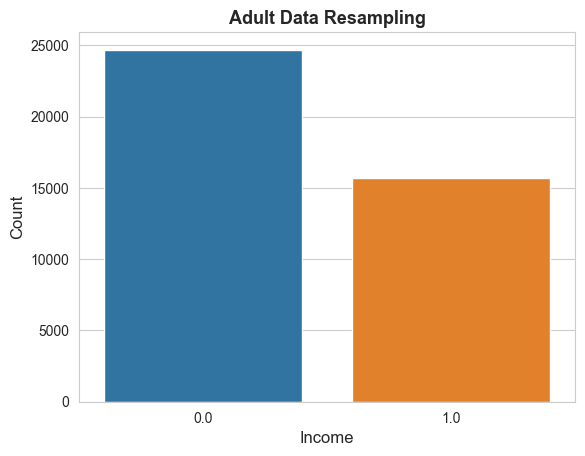

In [101]:
sns.countplot(x='Income', data=Adult_Data_Resampling, hue='Income', legend=False)
plt.title('Adult Data Resampling', fontsize=13, weight='bold')
plt.xlabel('Income', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Train Test Split

In [102]:
Adult_Data

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States,Income
0,39,6,1,40,7.68,0.0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,50,6,1,13,0.00,0.0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,38,2,1,40,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
3,53,1,1,40,0.00,0.0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
4,28,6,0,40,0.00,0.0,0,0,0,1,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,5,0,38,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
32533,40,2,1,40,0.00,0.0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,1
32534,58,2,0,40,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
32535,22,2,1,20,0.00,0.0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0


In [103]:
x_train_AE = Adult_Data_Resampling.drop('Income', axis=1)
y_train_AE = Adult_Data_Resampling['Income']

x_test = Adult_Test.drop('Income', axis=1)
y_test = Adult_Test['Income']
_ , x_test , _ , y_test = train_test_split(x_test, y_test, test_size=0.9999, random_state=42, shuffle=True)

x_train_original = Adult_Data.drop('Income', axis=1)
y_train_original  = Adult_Data['Income']
x_train_original , _  , y_train_original , _  = train_test_split(x_train_original , y_train_original , train_size=0.9999, random_state=42, shuffle=True)

x_train_AE, _ , y_train_AE, _ = train_test_split(x_train_AE, y_train_AE, train_size=0.9999, random_state=42, shuffle=True)
x_train_SMOTE, _ , y_train_SMOTE, _ = train_test_split(X_train_SMOTE, Y_train_SMOTE, train_size=0.9999, random_state=42, shuffle=True)
x_train_smotetomek, _ , y_train_smotetomek, _ = train_test_split(X_train_smotetomek, Y_train_smotetomek, train_size=0.9999, random_state=42, shuffle=True)
x_train_ros, _ , y_train_ros, _ = train_test_split(X_train_ROS, Y_train_ROS, train_size=0.9999, random_state=42, shuffle=True)

print(f'Number of Original Train Samples: {x_train_original.shape[0]}')
print(f'Number of Train AE Samples: {x_train_AE.shape[0]}')
print(f'Number of Train SMOTE Samples: {x_train_SMOTE.shape[0]}')
print(f'Number of Train SmoteTomek Samples: {x_train_smotetomek.shape[0]}')
print(f'Number of Train ROS Samples: {x_train_ros.shape[0]}')
print('########################################################')
print(f'Number of Test AE Samples: {x_test.shape[0]}')
print('########################################################')
print(f'Number of Train Features: {x_train_SMOTE.shape[1]}')
print(f'Number of Test Features: {x_test.shape[1]}')
print('########################################################')
print(f'Number of Original Train Targets: {y_train_original.shape[0]}')
print(f'Number of Train AE Targets: {y_train_AE.shape[0]}')
print(f'Number of Train SMOTE Targets: {y_train_SMOTE.shape[0]}')
print(f'Number of Train SmoteTomek Targets: {y_train_smotetomek.shape[0]}')
print(f'Number of Train ROS Targets: {y_train_ros.shape[0]}')
print(f'Number of Test Targets: {y_test.shape[0]}')

Number of Original Train Samples: 32533
Number of Train AE Samples: 40371
Number of Train SMOTE Samples: 37043
Number of Train SmoteTomek Samples: 35944
Number of Train ROS Samples: 33338
########################################################
Number of Test AE Samples: 16275
########################################################
Number of Train Features: 33
Number of Test Features: 33
########################################################
Number of Original Train Targets: 32533
Number of Train AE Targets: 40371
Number of Train SMOTE Targets: 37043
Number of Train SmoteTomek Targets: 35944
Number of Train ROS Targets: 33338
Number of Test Targets: 16275


# Normalization

In [104]:
minmaxscale = MinMaxScaler()

x_train_norm = x_train_original.copy()
x_test_norm = x_test.copy()

x_train = x_train_original.copy()
y_train = y_train_original.copy()

In [105]:
x_train_norm[disc_conti_features] = minmaxscale.fit_transform(x_train[disc_conti_features])
x_test_norm[disc_conti_features] = minmaxscale.transform(x_test[disc_conti_features])

In [106]:
x_train_norm.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,...,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000,32533.000000
mean,0.295696,0.299285,0.669197,0.402447,0.063884,0.041834,0.029478,0.064304,0.057081,0.696892,...,0.049089,0.453478,0.546522,0.031875,0.113854,0.854271,0.028832,0.055513,0.019642,0.896013
std,0.186821,0.252806,0.470509,0.125992,0.213367,0.189148,0.169144,0.245297,0.232000,0.459608,...,0.216056,0.497839,0.497839,0.175671,0.317638,0.352840,0.167337,0.228982,0.138767,0.305248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.125000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,0.273973,0.250000,1.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,0.424658,0.500000,1.000000,0.448980,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [107]:
x_test_norm.describe()

,age,education_num,sex,hours_per_week,log_capital_gain,log_capital_loss,workclass_Federal-gov,workclass_Local-gov,workclass_Other,workclass_Private,...,occupation_Transport-moving,relationship_Family,relationship_Other,race_Asian-Pac-Islander,race_Other,race_White,native_country_Level_1,native_country_Level_2,native_country_Mexico,native_country_United-States
count,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,...,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000,16275.000000
mean,0.298229,0.298149,0.666974,0.401966,0.062267,0.042053,0.029002,0.064086,0.059785,0.688541,...,0.046575,0.447558,0.552442,0.029493,0.113978,0.856528,0.026544,0.054009,0.018925,0.900522
std,0.189724,0.252131,0.471310,0.127318,0.210895,0.189702,0.167816,0.244914,0.237095,0.463104,...,0.210732,0.497257,0.497257,0.169189,0.317795,0.350564,0.160751,0.226043,0.136263,0.299312
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.125000,0.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,0.273973,0.250000,1.000000,0.397959,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,0.424658,0.500000,1.000000,0.448980,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.983294,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Feature Selection & Feature Reduction

## Constant Feature

In [108]:
varianc_thre = VarianceThreshold(threshold = 0)

varianc_thre.fit(x_train)
print(f'Number of Remained Features: {varianc_thre.get_support().sum()}')
print('Number of Removed Features: {}'.format(len(x_train.columns) - varianc_thre.get_support().sum()))

Number of Remained Features: 33
Number of Removed Features: 0


In [109]:
Variance = np.std(x_train[['age','hours_per_week','log_capital_gain','log_capital_loss','education_num']], axis=0).sort_values()
Variance

log_capital_loss     1.585039
education_num        2.022418
log_capital_gain     2.455818
hours_per_week      12.346981
age                 13.637726
dtype: float64

## Correlation

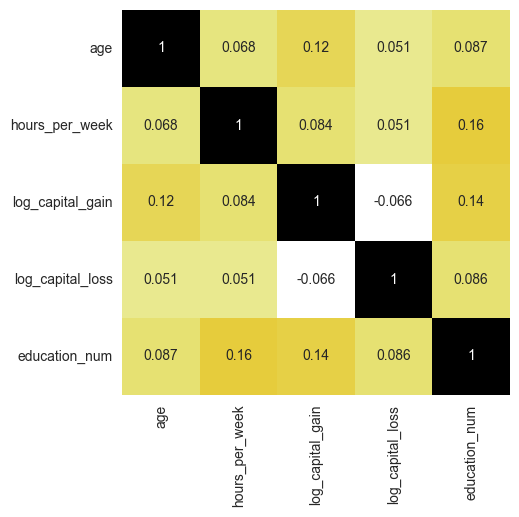

In [112]:
# Correlation between features

Corr_b_f = x_train[['age','hours_per_week','log_capital_gain','log_capital_loss','education_num']].corr()
plt.figure(figsize=(5,5))
sns.heatmap(Corr_b_f, annot=True, cbar=False, cmap=plt.cm.CMRmap_r)
plt.show()

In [114]:
# Correlation between features

def correlation(Dataset,Threshold):
    corrMatrix = Dataset.corr()
    num_features = len(Dataset.columns)
    corr = set()
    for i in range(num_features):
        for j in range(i):
            if abs(corrMatrix.iloc[i,j]) >= Threshold :
                first_column_name = corrMatrix.columns[i]
                second_column_name = corrMatrix.columns[j]
                corr.add((first_column_name,second_column_name))
    
    return corr
Corr_Thre = 0.9
features_high_correlation = correlation(x_train[['age','hours_per_week','log_capital_gain','log_capital_loss','education_num']]
                                        ,Corr_Thre)
print(f'Number Of Features With Higher Corralation than {Corr_Thre} : {len(features_high_correlation)}\n')
print(f'Features With Higher Corralation than {Corr_Thre} : {features_high_correlation}')

Number Of Features With Higher Corralation than 0.9 : 0

Features With Higher Corralation than 0.9 : set()


## Mutual Information

In [115]:
conti_features = ['age','fnlwgt','hours_per_week','education_num','log_capital_gain','log_capital_loss']
disc_cate_features = [x_train.columns.get_loc(col) for col in x_train.columns if col not in conti_features]

In [116]:
mutual_info = mutual_info_classif(x_train, y_train, discrete_features=disc_cate_features, n_neighbors=5)

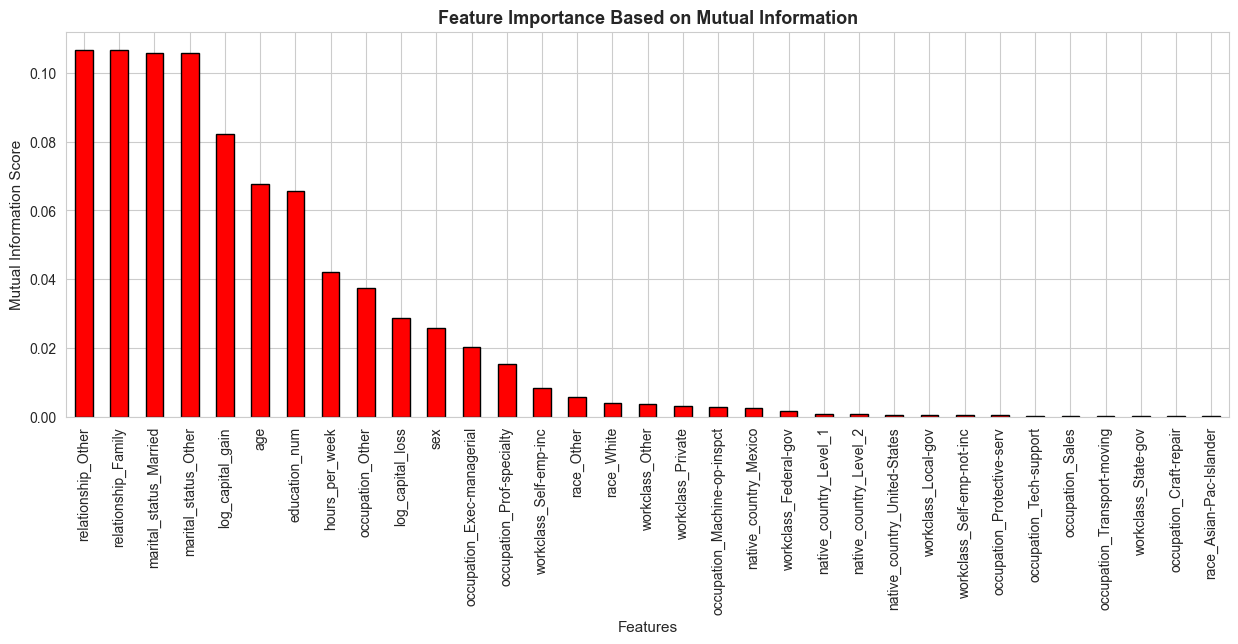

In [117]:
mutual_info_values = pd.Series(mutual_info, index=x_train.columns)
mutual_info_values.sort_values(ascending=False).plot.bar(figsize=(15, 5), color='red', edgecolor='black')
plt.title('Feature Importance Based on Mutual Information', fontsize=13, fontweight='bold')
plt.ylabel('Mutual Information Score', fontsize=11)
plt.xlabel('Features', fontsize=11)
plt.show()

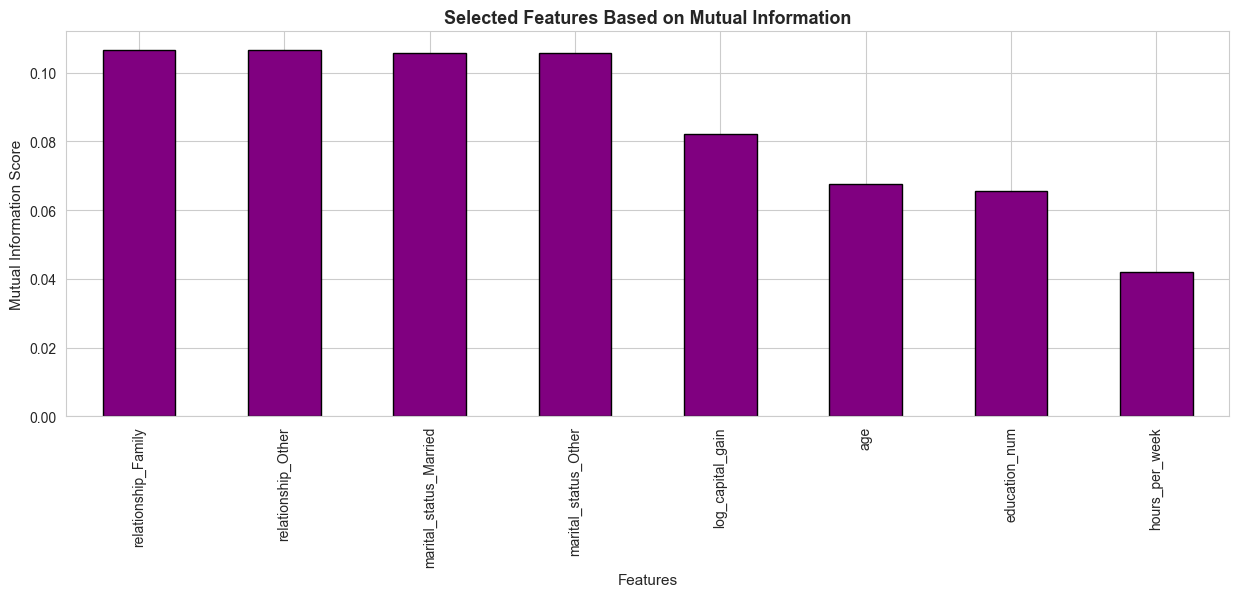

In [118]:
selected_feature_score_based_MI = mutual_info_values[mutual_info_values > 0.04]
selected_feature_score_based_MI.sort_values(ascending=False).plot.bar(figsize=(15, 5), color='purple', edgecolor='black')
plt.title('Selected Features Based on Mutual Information', fontsize=13, fontweight='bold')
plt.ylabel('Mutual Information Score', fontsize=11)
plt.xlabel('Features', fontsize=11)
plt.show()

In [119]:
Selected_Feature_Based_MI = selected_feature_score_based_MI.index.to_list()

## Tree

In [120]:
ETC_FI = ExtraTreesClassifier()
ETC_FI.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


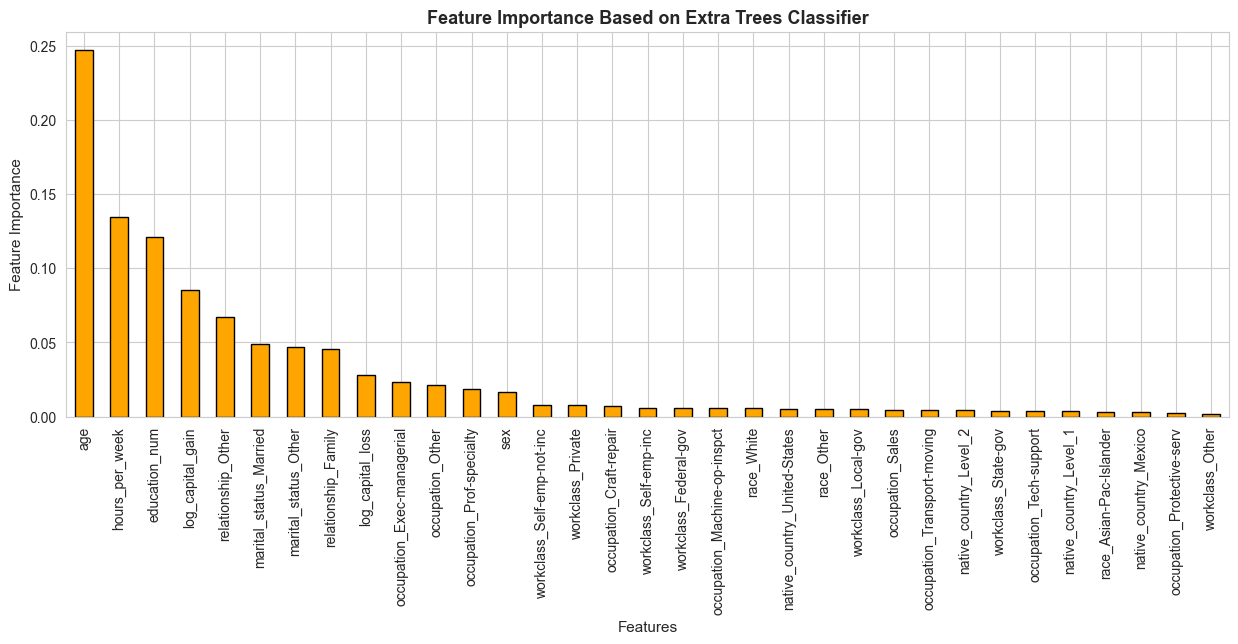

In [121]:
Rank_ETC = pd.Series(ETC_FI.feature_importances_, index=x_train.columns)
Rank_ETC.sort_values(ascending=False).plot.bar(figsize=(15, 5), color='orange', edgecolor='black')
plt.title('Feature Importance Based on Extra Trees Classifier', fontsize=13, fontweight='bold')
plt.ylabel('Feature Importance', fontsize=11)
plt.xlabel('Features', fontsize=11)
plt.show()

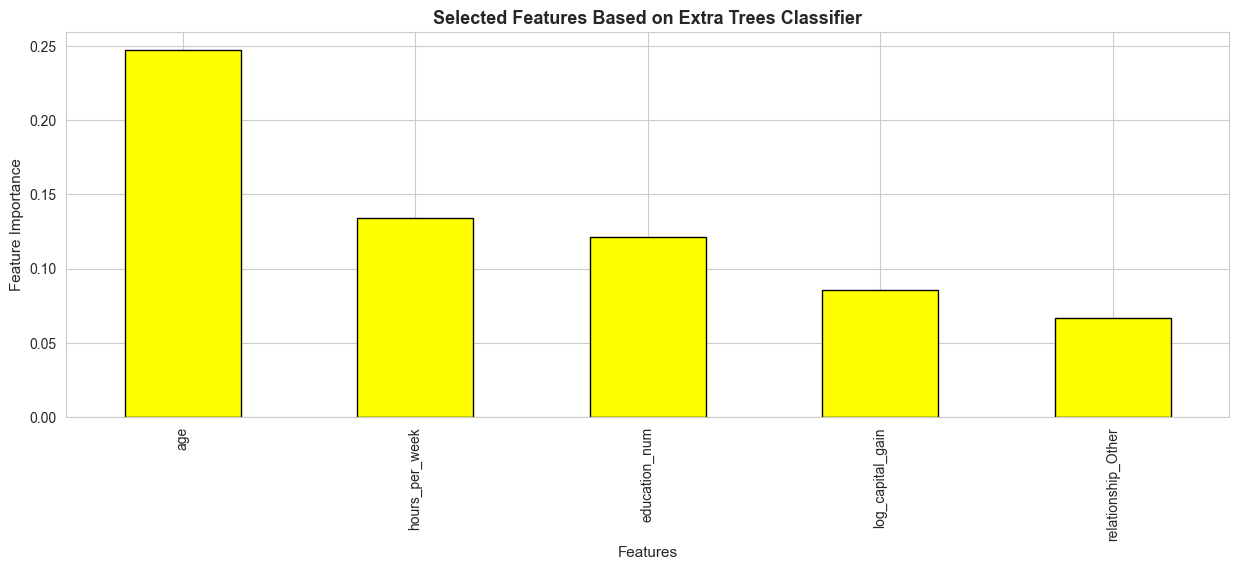

In [122]:
selected_feature_importance_ETC = Rank_ETC[ Rank_ETC > 0.05]
selected_feature_importance_ETC.sort_values(ascending=False).plot.bar(figsize=(15, 5), color='yellow', edgecolor='black')
plt.title('Selected Features Based on Extra Trees Classifier', fontsize=13, fontweight='bold')
plt.ylabel('Feature Importance', fontsize=11)
plt.xlabel('Features', fontsize=11)
plt.show()

In [123]:
Selected_Feature_Based_ETC = selected_feature_importance_ETC.index.to_list()

## RFE

In [124]:
ETC_model = ExtraTreesClassifier(random_state=42, n_jobs=-1)
RFE_ETC = RFECV(ETC_model, cv = StratifiedKFold(7, shuffle=True, random_state=42), scoring='f1', n_jobs=-1) 
RFE_ETC.fit(x_train,y_train)

,estimator,ExtraTreesCla...ndom_state=42)
,step,1
,min_features_to_select,1
,cv,StratifiedKFo... shuffle=True)
,scoring,'f1'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None


In [125]:
print("Num Features: %s" % (RFE_ETC.n_features_))
print("Feature Ranking: %s" % (RFE_ETC.ranking_)) 
print("Selected Feature names: %s" % (RFE_ETC.get_feature_names_out())) 

Num Features: 4
Feature Ranking: [ 1  1 10  2  1  5 16 20 30 11 17 13 26  4  6 15  8 18  7  9 29 23 25 19
  1  3 27 21 12 24 22 28 14]
Selected Feature names: ['age' 'education_num' 'log_capital_gain' 'relationship_Family']


In [126]:
selected_features_based_RFE = RFE_ETC.get_feature_names_out()

## Selected Features

In [127]:
print(f'Number of Selected Features Based on MI: {len(Selected_Feature_Based_MI)}')
print(f'Selected Features Based on MI: {Selected_Feature_Based_MI}')
print(' \n ===================================== \n')
print(f'Number of Selected Features Based on ETC: {len(Selected_Feature_Based_ETC)}')
print(f'Selected Features Based on ETC: {Selected_Feature_Based_ETC}')
print(' \n ===================================== \n')
print(f'Number of Selected Features Based on RFECV: {len(selected_features_based_RFE)}')
print(f'Selected Features Based on RFECV: {selected_features_based_RFE}')

Number of Selected Features Based on MI: 8
Selected Features Based on MI: ['age', 'education_num', 'hours_per_week', 'log_capital_gain', 'marital_status_Married', 'marital_status_Other', 'relationship_Family', 'relationship_Other']
 

Number of Selected Features Based on ETC: 5
Selected Features Based on ETC: ['age', 'education_num', 'hours_per_week', 'log_capital_gain', 'relationship_Other']
 

Number of Selected Features Based on RFECV: 4
Selected Features Based on RFECV: ['age' 'education_num' 'log_capital_gain' 'relationship_Family']


In [128]:
print(f'Number of Train Samples: {x_train.shape[0]}')
print(f'Number of Test Samples: {x_test.shape[0]}')
print('\n########################################## \n')
print(f'Number of Train Features: {x_train.shape[1]}')
print(f'Number of Test Features: {x_test.shape[1]}')
print('\n==========================================\n========================================== \n')
print(f'Number of Train Samples -RFE Data-: {x_train[selected_features_based_RFE].shape[0]}')
print(f'Number of Test Samples -RFE Data-: {x_test[selected_features_based_RFE].shape[0]}')
print('\n########################################## \n')
print(f'Number of Train Features -RFE Data-: {x_train[selected_features_based_RFE].shape[1]}')
print(f'Number of Test Features -RFE Data-: {x_test[selected_features_based_RFE].shape[1]}')
print('\n******************************************\n****************************************** \n')
print(f'Number of Train Targets: {y_train.shape[0]}')
print(f'Number of Test Targets: {y_test.shape[0]}')


Number of Train Samples: 32533
Number of Test Samples: 16275

########################################## 

Number of Train Features: 33
Number of Test Features: 33


Number of Train Samples -RFE Data-: 32533
Number of Test Samples -RFE Data-: 16275

########################################## 

Number of Train Features -RFE Data-: 4
Number of Test Features -RFE Data-: 4

******************************************
****************************************** 

Number of Train Targets: 32533
Number of Test Targets: 16275


## Saved

In [129]:
x_train_AE.to_csv('X_train_AE.csv', index=False)
y_train_AE.to_csv('Y_train_AE.csv', index=False)

x_train_SMOTE.to_csv('X_train_SMOTE.csv', index=False)
y_train_SMOTE.to_csv('Y_train_SMOTE.csv', index=False)

x_train_smotetomek.to_csv('X_train_smotetomek.csv', index=False)
y_train_smotetomek.to_csv('Y_train_smotetomek.csv', index=False)

x_train_ros.to_csv('X_train_ros.csv', index=False)
y_train_ros.to_csv('Y_train_ros.csv', index=False)

x_train_original.to_csv('X_train_original.csv', index=False)
y_train_original.to_csv('Y_train_original.csv', index=False)

x_test.to_csv('X_test.csv', index=False)
y_test.to_csv('Y_test.csv', index=False)
x_test[selected_features_based_RFE].to_csv('X_test_RFE.csv', index=False)
x_test[Selected_Feature_Based_MI].to_csv('X_test_MI.csv', index=False)

x_train_AE[selected_features_based_RFE].to_csv('X_train_AE_RFE.csv', index=False)
x_train_AE[Selected_Feature_Based_MI].to_csv('X_train_AE_MI.csv', index=False)

x_train_SMOTE[selected_features_based_RFE].to_csv('X_train_SMOTE_RFE.csv', index=False)
x_train_SMOTE[Selected_Feature_Based_MI].to_csv('X_train_SMOTE_MI.csv', index=False)

x_train_smotetomek[selected_features_based_RFE].to_csv('X_train_smotetomek_RFE.csv', index=False)
x_train_smotetomek[Selected_Feature_Based_MI].to_csv('X_train_smotetomek_MI.csv', index=False)

x_train_ros[selected_features_based_RFE].to_csv('X_train_ros_RFE.csv', index=False)
x_train_ros[Selected_Feature_Based_MI].to_csv('X_train_ros_MI.csv', index=False)

x_train_original[selected_features_based_RFE].to_csv('X_train_original_RFE.csv', index=False)
x_train_original[Selected_Feature_Based_MI].to_csv('X_train_original_MI.csv', index=False)

In [377]:
# END